<a href="https://colab.research.google.com/github/esalinasbio/taller-modelado-biomolecular/blob/master/notebooks/04_design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **<font color='616ACC'>Diseño computacional de proteínas *de novo*</font>**
### Parte 4 | Taller de modelado biomolecular

Este taller se enmarca en lo que se conoce como el "dogma central del diseño de
proteínas". Un modelo de difusión genera un *backbone* novedoso que define la forma
general de la proteína. Después, un modelo de plegamiento inverso propone secuencias de
aminoácidos que se adaptan a ese backbone de manera estable. Finalmente, un predictor de
estructura valida el modelo.

El ciclo es siempre el mismo:
*   Crear nuevas estructuras proteicas.
*   Diseñar secuencias plausibles.
*   Evaluar su viabilidad estructural.

Lo que cambió es la generación de herramientas:

| Paso | 2023 | Hoy |
|---|---|---|
| Estructura | RFdiffusion | **RFdiffusion3 (RFD3)**, todos los átomos |
| Secuencia | ProteinMPNN | **LigandMPNN / ProteinMPNN** |
| Validación | AlphaFold2 | **RoseTTAFold3 (RF3)** |

```
RFD3  ->  MPNN  ->  RF3  ->  RMSD
```


## **<font color='#4FD1C5'> 1. Configuración</font>**
*   Selecciona `Entorno de ejecución` (Runtime) -> `Cambiar tipo de entorno de ejecución`
    (Runtime type) -> `GPU`
*   `Conectar` en la esquina superior derecha
*   Usa el menú `Archivo` (`File`) para guardar una copia del
    notebook en tu Google Drive

Ahora corre las dos celdas siguientes. La instalación baja ~6 GB de pesos y no necesita
tu atención: déjala corriendo mientras vemos la teoría.

In [ ]:
#@title Verificar GPU
import subprocess, sys
try:
    salida = subprocess.check_output(["nvidia-smi", "--query-gpu=name,memory.total",
                                      "--format=csv,noheader"]).decode().strip()
    print("GPU detectada:", salida)
except Exception:
    print("NO hay GPU. Entorno de ejecucion -> Cambiar tipo de entorno -> GPU (T4).")
print("Python:", sys.version.split()[0])

In [ ]:
#@title Configurar notebook: **RFD3**, **MPNN** y **RF3**
#@markdown Se instala `rc-foundry`, que trae los tres modelos unificados sobre AtomWorks.
#@markdown Si la sesion se reinicia a medias, vuelve a correr esta celda: retoma donde iba.
import os, time

os.environ["DISABLE_CUEQUIVARIANCE"] = "1"

os.environ['CCD_MIRROR_PATH'] = ''
os.environ['PDB_MIRROR_PATH'] = ''

t0 = time.time()
if not os.path.isfile("FOUNDRY_READY"):
    print("Instalando rc-foundry ...")
    os.system("pip uninstall -y torchvision")
    os.system("pip install -q 'rc-foundry[all]'")
    os.system("pip install -q py3Dmol")
    os.system("touch FOUNDRY_READY")
else:
    print("rc-foundry ya estaba instalado.")

print("Descargando pesos (omite lo que ya este descargado) ...")
os.system("foundry install rfd3 ligandmpnn rf3")
print(f"Listo en {time.time() - t0:.0f} s.")

In [ ]:
#@title Cargar utilidades
import io, os, sys, time, logging, warnings
import numpy as np
from difflib import SequenceMatcher
import py3Dmol
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.collections import LineCollection
from IPython.display import display, HTML
import ipywidgets as widgets

from lightning.fabric import seed_everything
from biotite.structure import (get_residue_starts, filter_amino_acids,
                               rmsd, superimpose)
from biotite.structure.io.pdb import PDBFile
from biotite.sequence import ProteinSequence
from atomworks.constants import PROTEIN_BACKBONE_ATOM_NAMES
from rfd3.engine import RFD3InferenceConfig, RFD3InferenceEngine
from rfd3.inference.input_parsing import DesignInputSpecification
from mpnn.inference_engines.mpnn import MPNNInferenceEngine
from rf3.inference_engines.rf3 import RF3InferenceEngine
from rf3.utils.inference import InferenceInput

TEAL, AMBAR, GRIS = "#4FD1C5", "#F6AD55", "#A0AEC0"
PALETA = ["#4FD1C5", "#F6AD55", "#616ACC", "#F6ADCD", "#68D391", "#FC8181",
          "#B794F4", "#A0AEC0"]
BASES = ['A', 'U', 'G', 'C', 'DA', 'DT', 'DG', 'DC']


def silenciar_avisos(nivel=logging.ERROR):
    warnings.filterwarnings("ignore")
    logging.captureWarnings(True)
    logging.root.setLevel(nivel)
    for h in logging.root.handlers:
        h.setLevel(nivel)
    for nombre in list(logging.root.manager.loggerDict):
        lg = logging.getLogger(nombre)
        lg.setLevel(nivel)
        for h in lg.handlers:
            h.setLevel(nivel)


def desactivar_cuequivariance():
    tocados = []
    for nombre, modulo in list(sys.modules.items()):
        try:
            if modulo.__dict__.get("SHOULD_USE_CUEQUIVARIANCE", False):
                modulo.__dict__["SHOULD_USE_CUEQUIVARIANCE"] = False
                tocados.append(nombre)
        except Exception:
            continue
    return tocados


def a_pdb(aa):
    aa = aa.copy()
    for campo in ("b_factor", "occupancy"):
        if campo in aa.get_annotation_categories():
            v = np.asarray(aa.get_annotation(campo), dtype=float)
            v = np.nan_to_num(v, nan=0.0, posinf=999.0, neginf=0.0)
            aa.set_annotation(campo, np.clip(v, 0.0, 999.0))
    f = PDBFile()
    f.set_structure(aa)
    buf = io.StringIO()
    f.write(buf)
    return buf.getvalue()


def secuencia(aa):
    """Secuencia de 1 letra de la proteina"""
    prot = aa[filter_amino_acids(aa)]
    if len(prot) == 0:
        return ""
    letras = []
    for rn in prot.res_name[get_residue_starts(prot)]:
        try:
            letras.append(ProteinSequence.convert_letter_3to1(rn))
        except Exception:
            letras.append("X")
    return "".join(letras)


def identidad(s1, s2):
    n = min(len(s1), len(s2))
    return float('nan') if n == 0 else 100.0 * sum(a == b for a, b in zip(s1, s2)) / n


def backbone_proteico(aa):
    m = filter_amino_acids(aa) & np.isin(aa.atom_name, list(PROTEIN_BACKBONE_ATOM_NAMES))
    return aa[m]


def rmsd_backbone(ref, movil):
    r, m = backbone_proteico(ref), backbone_proteico(movil)
    n = min(len(r), len(m))
    if len(r) != len(m):
        print(f"  aviso: {len(r)} vs {len(m)} atomos de backbone; comparo los primeros {n}")
    ajustada, _ = superimpose(r[:n], m[:n])
    return float(rmsd(r[:n], ajustada))


def superponer(ref, movil):
    """Devuelve `movil` alineada al backbone de `ref`."""
    r, m = backbone_proteico(ref), backbone_proteico(movil)
    n = min(len(r), len(m))
    _, transformacion = superimpose(r[:n], m[:n])
    return transformacion.apply(movil)


def radio_de_giro(aa):
    ca = aa[filter_amino_acids(aa) & (aa.atom_name == "CA")]
    if len(ca) == 0:
        return float('nan')
    return float(np.sqrt(((ca.coord - ca.coord.mean(0)) ** 2).sum(1).mean()))


def contactos_interfaz(aa, corte=5.0):
    """Residuos de proteina a menos de `corte` de un acido nucleico."""
    es_prot, es_na = filter_amino_acids(aa), np.isin(aa.res_name, BASES)
    if es_na.sum() == 0 or es_prot.sum() == 0:
        return 0, float('nan')
    P, N = aa[es_prot], aa[es_na]
    d = np.linalg.norm(P.coord[:, None, :] - N.coord[None, :, :], axis=-1)
    cerca = (d < corte).any(axis=1)
    return len(set(zip(P.chain_id[cerca], P.res_id[cerca]))), float(d.min())


def contactos_ligando(aa, nombres, corte=5.0):
    """Residuos de proteina a menos de `corte` A de un ligando dado por res_name."""
    es_prot = filter_amino_acids(aa)
    es_lig = np.isin(aa.res_name, list(nombres))
    if es_lig.sum() == 0 or es_prot.sum() == 0:
        return 0, float('nan')
    P, L = aa[es_prot], aa[es_lig]
    d = np.linalg.norm(P.coord[:, None, :] - L.coord[None, :, :], axis=-1)
    cerca = (d < corte).any(axis=1)
    return len(set(zip(P.chain_id[cerca], P.res_id[cerca]))), float(d.min())


def resumen(aa, etiqueta="estructura"):
    prot = aa[filter_amino_acids(aa)]
    n_res = len(get_residue_starts(prot)) if len(prot) else 0
    cadenas = ", ".join(sorted(set(str(c) for c in aa.chain_id)))
    print(f"--- {etiqueta} ---")
    print(f"  atomos: {len(aa)} | residuos de proteina: {n_res} | cadenas: {cadenas}")
    if n_res:
        print(f"  Rg (CA): {radio_de_giro(aa):.1f} A "
              f"(globular de {n_res} res: ~{2.2 * n_res ** 0.38:.1f} A)")
    if np.isin(aa.res_name, BASES).sum():
        n_c, d_min = contactos_interfaz(aa)
        print(f"  interfaz con acido nucleico: {n_c} residuos a <5 A "
              f"(minima {d_min:.2f} A)")
    return n_res


def preparar_pdb(codigo, cadenas=None, quitar_hetero=True):
    """Descarga un PDB, se queda con las cadenas pedidas y lo guarda recortado."""
    crudo = f"{codigo}.pdb"
    if not os.path.isfile(crudo):
        os.system(f"wget -q https://files.rcsb.org/download/{codigo}.pdb")
    if not os.path.isfile(crudo):
        raise FileNotFoundError(f"No se pudo descargar {codigo} de la PDB.")
    aa = PDBFile.read(crudo).get_structure(model=1)
    aa = aa[aa.element != "H"]
    aa = aa[aa.res_name != "HOH"]
    if cadenas:
        aa = aa[np.isin(aa.chain_id, list(cadenas))]
    if quitar_hetero:
        es_polimero = filter_amino_acids(aa) | np.isin(aa.res_name, BASES)
        aa = aa[es_polimero]
    ruta = f"{codigo}_recortado.pdb"
    f = PDBFile()
    f.set_structure(aa)
    f.write(ruta)
    print(f"{codigo.upper()} -> {ruta}")
    for c in sorted(set(aa.chain_id)):
        sub = aa[aa.chain_id == c]
        ids = sorted(set(sub.res_id))
        tipo = "proteina" if filter_amino_acids(sub).any() else "acido nucleico"
        print(f"  cadena {c}: {tipo}, residuos {ids[0]}-{ids[-1]} ({len(ids)})")
    print(f"  centro de masa: {np.round(aa.coord.mean(0), 1)}")
    return ruta, aa


def make_animation(xyz, Ls=None, bfact=None, color="rainbow", dpi=100,
                   intervalo=120, max_cuadros=40):
    """Pelicula del trazo de carbonos alfa a lo largo de la difusion."""
    xyz = np.asarray(xyz, dtype=float)
    if len(xyz) > max_cuadros:
        idx = np.linspace(0, len(xyz) - 1, max_cuadros).astype(int)
        xyz = xyz[idx]
        if bfact is not None and np.ndim(bfact) == 2:
            bfact = np.asarray(bfact)[idx]
    n_cuadros, n_res, _ = xyz.shape

    referencia = xyz[-1]
    xyz = np.asarray(superimpose(referencia, xyz)[0])
    _, _, ejes = np.linalg.svd(referencia - referencia.mean(0), full_matrices=False)
    proy = xyz @ ejes[:2].T
    proy = proy - proy[-1].mean(0)
    lim = np.abs(proy).max() * 1.05 + 2.0

    mascara = None
    if Ls and len(Ls) > 1:
        cortes = (np.cumsum(Ls)[:-1] - 1).astype(int)
        mascara = np.ones(n_res - 1, dtype=bool)
        mascara[cortes] = False

    if color == "chain" and Ls:
        idx_cadena = np.concatenate([[i] * L for i, L in enumerate(Ls)])
        colores_res = np.array([PALETA[i % len(PALETA)] for i in idx_cadena])
    elif color == "rainbow" or bfact is None:
        colores_res = plt.cm.rainbow(np.linspace(0, 1, n_res))
    else:
        colores_res = None

    fig, ax = plt.subplots(figsize=(5, 5), dpi=dpi)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal"); ax.axis("off")
    titulo = ax.set_title("", fontsize=10)
    lc = LineCollection([], linewidths=3.0, capstyle="round")
    ax.add_collection(lc)

    def dibujar(k):
        p = proy[k]
        s = np.stack([p[:-1], p[1:]], axis=1)
        if mascara is not None:
            s = s[mascara]
        lc.set_segments(s)
        if colores_res is not None:
            c = colores_res[:-1]
            if mascara is not None:
                c = c[mascara]
            lc.set_color(list(c))
        else:
            v = bfact[k] if np.ndim(bfact) == 2 else bfact
            v = np.asarray(v, dtype=float)[:-1]
            if mascara is not None:
                v = v[mascara]
            lc.set_array(v); lc.set_cmap("RdYlBu"); lc.set_clim(np.min(v), np.max(v))
        titulo.set_text(f"cuadro {k + 1} / {n_cuadros}")
        return (lc,)

    dibujar(0)
    anim = animation.FuncAnimation(fig, dibujar, frames=n_cuadros,
                                   interval=intervalo, blit=False)
    html = anim.to_jshtml()
    plt.close(fig)
    return html


def _ca_de_stack(stack):
    plantilla = stack[0]
    mascara = plantilla.atom_name == "CA"
    if mascara.sum() == 0:
        mascara = np.zeros(len(plantilla), dtype=bool)
        mascara[get_residue_starts(plantilla)] = True
    Ls = [int((plantilla.chain_id[mascara] == c).sum())
          for c in dict.fromkeys(plantilla.chain_id[mascara])]
    return stack.coord[:, mascara, :], Ls


def _nombres_ligando(aa):
    m = ~(filter_amino_acids(aa) | np.isin(aa.res_name, BASES))
    return sorted(set(str(x) for x in aa.res_name[m]) - {"ORI", "HOH"})


def residuos_cerca_de_ligando(aa, corte=5.0):
    ligs = _nombres_ligando(aa)
    es_prot, es_lig = filter_amino_acids(aa), np.isin(aa.res_name, ligs)
    if not ligs or es_lig.sum() == 0 or es_prot.sum() == 0:
        return {}
    P, L = aa[es_prot], aa[es_lig]
    d = np.linalg.norm(P.coord[:, None, :] - L.coord[None, :, :], axis=-1)
    cerca = (d < corte).any(axis=1)
    fuera = {}
    for c, r in set(zip(P.chain_id[cerca], P.res_id[cerca])):
        fuera.setdefault(str(c), []).append(int(r))
    return fuera


def _dibujar_estatico(aa, color="rainbow", superficie=False, extra=None, sitio=0.0):
    v = py3Dmol.view(width=720, height=480, js='https://3dmol.org/build/3Dmol.js')
    v.addModel(a_pdb(aa), 'pdb', {'hbondCutoff': 4.0, 'keepH': True})
    if color == "rainbow":
        v.setStyle({'model': 0}, {'cartoon': {'color': 'spectrum'}})
    elif color == "chain":
        for i, c in enumerate(sorted(set(aa.chain_id))):
            v.setStyle({'model': 0, 'chain': c},
                       {'cartoon': {'color': PALETA[i % len(PALETA)]}})
    else:  # b-factor: en RFD3 es la confianza
        v.setStyle({'model': 0}, {'cartoon': {'colorscheme': {
            'prop': 'b', 'gradient': 'roygb', 'min': 0.5, 'max': 0.9}}})
    v.addStyle({'model': 0, 'resn': BASES}, {'stick': {'radius': 0.18, 'color': AMBAR}})

    # ligandos: sin esto quedan invisibles, porque el cartoon no los dibuja
    ligs = _nombres_ligando(aa)
    if ligs:
        v.addStyle({'model': 0, 'resn': ligs},
                   {'stick': {'radius': 0.28, 'colorscheme': 'greenCarbon'}})
        v.addStyle({'model': 0, 'resn': ligs}, {'sphere': {'scale': 0.22}})

    # residuos del bolsillo, incluidos los cataliticos
    if sitio and sitio > 0:
        for c, ids in residuos_cerca_de_ligando(aa, corte=sitio).items():
            v.addStyle({'model': 0, 'chain': c, 'resi': ids},
                       {'stick': {'radius': 0.16, 'colorscheme': 'whiteCarbon'}})

    if superficie:
        v.addSurface(py3Dmol.SAS, {'opacity': 0.4, 'color': 'white'}, {'model': 0})
    if extra is not None:
        v.addModel(a_pdb(extra), 'pdb', {'keepH': True})
        v.setStyle({'model': 1}, {'cartoon': {'color': GRIS}})
        ligs2 = _nombres_ligando(extra)
        if ligs2:
            v.addStyle({'model': 1, 'resn': ligs2},
                       {'stick': {'radius': 0.2, 'color': GRIS}})
    v.zoomTo()
    v.show()


def ver(aa, color="rainbow", superficie=False, extra=None, sitio=0.0):
    """Muestra una estructura (y opcionalmente otra encima, en gris)."""
    _dibujar_estatico(aa, color=color, superficie=superficie, extra=extra, sitio=sitio)


def ver_palitos(aa, ancho=720, alto=480):
    """Vista de palitos y esferas: para sitios activos y ligandos sueltos,
    donde el cartoon no dibuja nada porque no hay cadena continua."""
    v = py3Dmol.view(width=ancho, height=alto, js='https://3dmol.org/build/3Dmol.js')
    v.addModel(a_pdb(aa), 'pdb', {'keepH': True})
    v.setStyle({}, {'stick': {'radius': 0.15, 'colorscheme': 'default'}})
    v.addStyle({'hetflag': True}, {'sphere': {'scale': 0.28}})
    v.zoomTo()
    v.show()


def pintar_plddt(prediccion, estructura=None):
    """Copia la estructura con el pLDDT por atomo metido en el b-factor."""
    aa = (estructura if estructura is not None else prediccion.atom_array).copy()
    valores = prediccion.confidences.get("atom_plddts") if prediccion.confidences else None
    if valores is None:
        print("  esta prediccion no trae atom_plddts")
        return None
    v = np.asarray(valores, dtype=float)
    if len(v) != len(aa):
        print(f"  aviso: {len(v)} pLDDTs para {len(aa)} atomos, no los puedo mapear")
        return None
    if v.max() > 1.5:          # algunos modelos lo reportan en 0-100
        v = v / 100.0
    aa.set_annotation("b_factor", v)
    return aa


def ver_confianza(prediccion, estructura=None, referencia=None, por_cadena=True):
    aa = pintar_plddt(prediccion, estructura)
    if aa is None:
        return
    if por_cadena:
        b = aa.get_annotation("b_factor")
        print("  pLDDT promedio por cadena:")
        for c in sorted(set(str(x) for x in aa.chain_id)):
            m = aa.chain_id == c
            print(f"    cadena {c}: {b[m].mean():.3f}  (min {b[m].min():.3f})")
    ver(aa, color="bfactor", extra=referencia)


def mostrar(salidas, animate="movie", color="rainbow", dpi=100,
            superficie=False, sitio=0.0):
    """Reproduce el visor del taller original: none / movie / interactive.

    `salidas` es lo que devuelve `disenar()`. Si hay mas de un diseno, aparece un
    menu desplegable para elegir cual ver.
    """
    items = [(k, o) for k, lista in salidas.items() for o in lista]

    def pintar(n=0):
        clave, salida = items[n]
        aa = salida.atom_array
        if animate == "none":
            _dibujar_estatico(aa, color=color, superficie=superficie,
                              sitio=sitio)
            return
        traj = salida.denoised_trajectory_stack
        if traj is None:
            print("No hay trayectoria guardada (corre con trayectoria=True). "
                  "Muestro la estructura final.")
            _dibujar_estatico(aa, color=color, superficie=superficie,
                              sitio=sitio)
            return
        if animate == "interactive":
            try:
                f = PDBFile(); f.set_structure(traj)
                buf = io.StringIO(); f.write(buf)
                v = py3Dmol.view(width=720, height=480,
                                 js='https://3dmol.org/build/3Dmol.js')
                v.addModelsAsFrames(buf.getvalue(), 'pdb', {'hbondCutoff': 4.0})
                v.setStyle({'cartoon': {'color': 'spectrum'}})
                v.addStyle({}, {'line': {}})
                v.zoomTo()
                v.animate({'loop': 'backAndForth'})
                v.show()
            except Exception as e:
                print("La trayectoria no se pudo escribir como PDB:", e)
                print("Usa animate='movie' en su lugar.")
        else:
            xyz, Ls = _ca_de_stack(traj)
            display(HTML(make_animation(xyz, Ls=Ls, color=color, dpi=dpi)))

    if len(items) > 1:
        salida_w = widgets.Output()
        menu = widgets.Dropdown(options=[(f"{i}", i) for i in range(len(items))],
                                value=0, description='diseño:')
        def al_cambiar(cambio):
            if cambio['name'] == 'value':
                with salida_w:
                    salida_w.clear_output(wait=True)
                    pintar(cambio['new'])
        menu.observe(al_cambiar)
        display(widgets.VBox([menu, salida_w]))
        with salida_w:
            pintar(0)
    else:
        pintar(0)


def cadena_secuencia(aa):
    letras = []
    for rn in aa.res_name[get_residue_starts(aa)]:
        if rn in BASES:
            letras.append(rn[-1].lower())
        else:
            try:
                letras.append(ProteinSequence.convert_letter_3to1(rn))
            except Exception:
                letras.append("X")
    return "".join(letras)


def _subcadena_comun(a, b):
    if not a or not b:
        return 0
    return SequenceMatcher(None, a, b, autojunk=False).find_longest_match(
        0, len(a), 0, len(b)).size


def identificar_cadenas(diseno, entrada=None, ancho=60):
    seqs_entrada = {}
    if entrada is not None:
        aa_ent = entrada
        if isinstance(entrada, str):
            aa_ent = PDBFile.read(entrada).get_structure(model=1)
            aa_ent = aa_ent[(aa_ent.element != "H") & (aa_ent.res_name != "HOH")]
        for c in sorted(set(str(x) for x in aa_ent.chain_id)):
            seqs_entrada[c] = cadena_secuencia(aa_ent[aa_ent.chain_id == c])

    disenadas, fijas = [], []
    print(f"{'cad':>4} {'tipo':<16} {'res':>4}  estado")
    print("-" * 72)
    for c in sorted(set(str(x) for x in diseno.chain_id)):
        sub = diseno[diseno.chain_id == c]
        s = cadena_secuencia(sub)
        es_prot = filter_amino_acids(sub).any()
        es_na = np.isin(sub.res_name, BASES).any()
        if not es_prot and not es_na:
            # ligando, ion o token ORI: ni se disena ni se templa
            nombres = ",".join(sorted(set(str(x) for x in sub.res_name)))[:30]
            print(f"{c:>4} {'ligando/otro':<16} {len(set(sub.res_id)):>4}  "
                  f"se deja como esta ({nombres})")
            continue
        tipo = "acido nucleico" if es_na else "proteina"
        n, origen = (max((_subcadena_comun(s, e), o) for o, e in seqs_entrada.items())
                     if seqs_entrada else (0, "?"))
        if n == len(s) and n > 0:
            estado = f"FIJA, es la cadena {origen} del archivo de entrada"
            fijas.append(c)
        elif n >= 6:
            estado = f"DISEÑADA, con {n} residuos de la cadena {origen} incrustados"
            disenadas.append(c)
        else:
            estado = "DISEÑADA, todo nuevo"
            disenadas.append(c)
        print(f"{c:>4} {tipo:<16} {len(s):>4}  {estado}")
        print(f"     {s[:ancho]}{'...' if len(s) > ancho else ''}")

    print(f"\n  diseñadas: '{''.join(disenadas)}'    fijas: '{''.join(fijas)}'")
    if not seqs_entrada:
        print("  (pasa entrada=<ruta del pdb> para poder comparar)")
    return "".join(disenadas), "".join(fijas)


def seleccion_de_cadena(aa, cadenas):
    sel = []
    for c in list(cadenas or ""):
        sub = aa[aa.chain_id == c]
        if len(sub):
            sel.append(f"{c}{int(sub.res_id.min())}-{int(sub.res_id.max())}")
    return sel


def rmsd_por_cadena(ref, prediccion, alinear_en=None):
    movida = None
    if alinear_en:
        r = backbone_proteico(ref[np.isin(ref.chain_id, list(alinear_en))])
        m = backbone_proteico(prediccion[np.isin(prediccion.chain_id, list(alinear_en))])
        n = min(len(r), len(m))
        if n:
            _, tr = superimpose(r[:n], m[:n])
            movida = tr.apply(prediccion)
        else:
            print("  no encontre esa cadena en la prediccion; alineo sobre todo")
    if movida is None:
        movida = superponer(ref, prediccion)

    print(f"  alineado sobre: {alinear_en or 'todas las cadenas'}")
    for c in sorted(set(str(x) for x in ref.chain_id)):
        r = backbone_proteico(ref[ref.chain_id == c])
        m = backbone_proteico(movida[movida.chain_id == c])
        if len(r) == 0 or len(m) == 0:
            continue
        n = min(len(r), len(m))
        d = float(np.sqrt(((r[:n].coord - m[:n].coord) ** 2).sum(1).mean()))
        marca = "  <- blanco (plantilla)" if alinear_en and c in alinear_en else ""
        print(f"  cadena {c}: RMSD {d:.2f} A{marca}")
    return movida



_MOTORES = {}

def _mpnn(tipo):
    if tipo not in _MOTORES:
        _MOTORES[tipo] = MPNNInferenceEngine(
            model_type=tipo, is_legacy_weights=True, out_directory=None,
            write_structures=False, write_fasta=False)
    return _MOTORES[tipo]


def _rf3():
    if "rf3" not in _MOTORES:
        _MOTORES["rf3"] = RF3InferenceEngine(ckpt_path='rf3', verbose=False)
    return _MOTORES["rf3"]


def disenar(spec=None, longitud=None, n_disenos=1, pasos=50, semilla=0,
            trayectoria=True, simetria=False, **muestreador):
    """Corre RFD3.

    spec     : DesignInputSpecification, o un diccionario de campos, o None
    longitud : atajo para difusion no condicionada
    pasos    : num_timesteps de la difusion
    **muestreador: opciones extra del sampler (step_scale, gamma_0, ...)
    """
    silenciar_avisos()
    seed_everything(semilla)
    opciones = {"num_timesteps": pasos, **muestreador}
    if simetria:
        opciones["kind"] = "symmetry"
    comun = dict(diffusion_batch_size=n_disenos, inference_sampler=opciones,
                 dump_trajectories=trayectoria)

    t0 = time.time()
    if isinstance(spec, DesignInputSpecification):
        motor = RFD3InferenceEngine(**RFD3InferenceConfig(**comun))
        salidas = motor.run(inputs=spec, out_dir=None, n_batches=1)
    else:
        campos = dict(spec or {})
        if longitud is not None:
            campos["length"] = longitud
        motor = RFD3InferenceEngine(**RFD3InferenceConfig(specification=campos, **comun))
        salidas = motor.run(inputs=None, out_dir=None, n_batches=1)
    print(f"[RFD3] {time.time() - t0:.0f} s")
    return salidas


def elegir(salidas, n=0):
    """Saca el n-esimo AtomArray de lo que devuelve disenar()."""
    items = [o for lista in salidas.values() for o in lista]
    return items[n].atom_array


def validar(aa, n_secuencias=8, temperatura=0.1, tipo_mpnn="ligand_mpnn",
            cadenas_disenadas=None, plantilla=None, semilla=0,
            cual_replegar=0, ver_resultado=True, vista="cadena",
            homo_oligomero=False, replegar_solo=None):
    """MPNN + RF3 + RMSD: el ciclo de auto-consistencia completo.

    plantilla: cadenas del blanco que RF3 NO debe replegar desde cero. Sin esto,
    RF3 intentaria predecir una proteina natural sin MSA, y eso no le sale.
    """
    silenciar_avisos()
    print("=" * 62)
    print(f"MPNN ({tipo_mpnn}): {n_secuencias} secuencias, temperatura {temperatura}")
    entrada = {"batch_size": n_secuencias, "temperature": temperatura,
               "seed": semilla, "remove_waters": True}
    if cadenas_disenadas:
        entrada["designed_chains"] = list(cadenas_disenadas)
    if homo_oligomero:
        # ata las secuencias de todas las subunidades: un homo-oligomero de verdad
        cadenas = [str(c) for c in dict.fromkeys(aa.chain_id)]
        entrada["homo_oligomer_chains"] = [cadenas]
        print(f"  secuencias atadas entre subunidades: {cadenas}")
    t0 = time.time()
    try:
        salidas_mpnn = _mpnn(tipo_mpnn).run(input_dicts=[entrada], atom_arrays=[aa])
    except Exception as e:
        print("  fallo con designed_chains, reintento sin esa restriccion:", e)
        entrada.pop("designed_chains", None)
        salidas_mpnn = _mpnn(tipo_mpnn).run(input_dicts=[entrada], atom_arrays=[aa])
    print(f"[MPNN] {time.time() - t0:.0f} s")

    seq_rfd3 = secuencia(aa)
    secuencias = [secuencia(s.atom_array) for s in salidas_mpnn]
    print(f"\nRFD3  : {seq_rfd3}")
    for i, s in enumerate(secuencias):
        print(f"MPNN {i + 1:2d}: {s}   (identidad vs RFD3: {identidad(s, seq_rfd3):.0f}%)")
    pares = [identidad(secuencias[i], secuencias[j])
             for i in range(len(secuencias)) for j in range(i + 1, len(secuencias))]
    if pares:
        print(f"\nIdentidad promedio entre secuencias de MPNN: {np.mean(pares):.0f}%")
    basicos = 100 * sum(secuencias[0].count(a) for a in "RK") / max(len(secuencias[0]), 1)
    hidrof = 100 * sum(secuencias[0].count(a) for a in "AVLIMFWC") / max(len(secuencias[0]), 1)
    print(f"Primera secuencia: {hidrof:.0f}% hidrofobicos (tipico 30-35%), "
          f"{basicos:.0f}% Arg+Lys (tipico ~11%)")

    print(f"\nRF3: replegando la secuencia {cual_replegar + 1} ...")
    t0 = time.time()
    aa_mpnn = salidas_mpnn[cual_replegar].atom_array
    referencia = aa
    if replegar_solo:
        aa_mpnn = aa_mpnn[np.isin(aa_mpnn.chain_id, list(replegar_solo))]
        referencia = aa[np.isin(aa.chain_id, list(replegar_solo))]
        print(f"  replegando solo la cadena {replegar_solo}, no el ensamble completo")
    seleccion = seleccion_de_cadena(aa_mpnn, plantilla) if plantilla else None
    if seleccion:
        print(f"  plantilla, no se repliega desde cero: {seleccion}")
    try:
        entrada_rf3 = InferenceInput.from_atom_array(
            aa_mpnn, example_id="diseno", template_selection=seleccion)
    except Exception as e:
        print("  no pude usar la salida de MPNN, repliego la secuencia de RFD3:", e)
        entrada_rf3 = InferenceInput.from_atom_array(
            referencia, example_id="diseno", template_selection=seleccion)
    prediccion = _rf3().run(inputs=entrada_rf3)["diseno"][0]
    print(f"[RF3] {time.time() - t0:.0f} s")

    conf = prediccion.summary_confidences
    print(f"\n  pLDDT global : {conf['overall_plddt']:.3f}   (bueno: > 0.80)")
    print(f"  pTM          : {conf['ptm']:.3f}   (bueno: > 0.70)")
    iptm = conf.get('iptm', None)
    if iptm is None or float(iptm) == 0.0:
        print("  ipTM         : no aplica (una sola cadena, no hay interfaz que medir)")
    else:
        print(f"  ipTM         : {float(iptm):.3f}   <- confianza en la interfaz")
    print(f"  choques      : {conf['has_clash']}")

    if plantilla:
        print("\n  RMSD por cadena:")
        movida = rmsd_por_cadena(referencia, prediccion.atom_array, alinear_en=plantilla)
        valor = float('nan')
    else:
        valor = rmsd_backbone(referencia, prediccion.atom_array)
        movida = superponer(referencia, prediccion.atom_array)
        print(f"  RMSD backbone (diseño vs replegado): {valor:.2f} A")
        if valor < 1.0:
            v = "excelente"
        elif valor < 2.0:
            v = "bueno, pasa el filtro estandar de diseñabilidad"
        elif valor < 4.0:
            v = "dudoso, la topologia coincide pero hay desviaciones grandes"
        else:
            v = "malo, la secuencia no recupera el backbone"
        print(f"  Veredicto: {v}")
    print("  Recuerda: es auto-consistencia entre dos redes, no evidencia experimental.")

    if ver_resultado:
        if vista == "plddt":
            ver_confianza(prediccion, estructura=movida, referencia=referencia)
        else:
            ver(referencia, color="chain", extra=movida)
    return {"mpnn": salidas_mpnn, "secuencias": secuencias,
            "rf3": prediccion, "rmsd": valor}

# guardar
CARPETA_RESULTADOS = "resultados_taller"

def montar_drive(subcarpeta="taller_diseno"):
    """Monta Google Drive y devuelve la carpeta donde se guardara todo."""
    global CARPETA_RESULTADOS
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        CARPETA_RESULTADOS = f"/content/drive/MyDrive/{subcarpeta}"
    except Exception as e:
        print("No pude montar Drive, guardo en el disco local de Colab:", e)
        CARPETA_RESULTADOS = subcarpeta
    os.makedirs(CARPETA_RESULTADOS, exist_ok=True)
    print("Los resultados se guardaran en:", CARPETA_RESULTADOS)
    return CARPETA_RESULTADOS


def guardar_ejercicio(nombre, salidas=None, estructura=None, resultado=None,
                      entrada=None, trayectorias=False):
    """Escribe a disco todo lo de un ejercicio.

    nombre       : subcarpeta, p.ej. "3_no_condicionada"
    salidas      : lo que devolvio disenar() (guarda cada diseño en CIF)
    estructura   : el AtomArray elegido (guarda tambien un PDB, mas portatil)
    resultado    : lo que devolvio validar() (secuencias de MPNN y modelo de RF3)
    entrada      : ruta del pdb de entrada, para copiarlo junto a los resultados
    trayectorias : guarda tambien la pelicula de denoising (archivos grandes)
    """
    import json as _json
    import shutil
    from atomworks.io.utils.io_utils import to_cif_file

    carpeta = os.path.join(CARPETA_RESULTADOS, nombre)
    os.makedirs(carpeta, exist_ok=True)
    escritos = []

    def _ruta(*partes):
        return os.path.join(carpeta, "_".join(str(p) for p in partes))

    if salidas is not None:
        for k, (clave, salida) in enumerate(
                [(k, o) for k, lista in salidas.items() for o in lista]):
            try:
                to_cif_file(salida.atom_array, _ruta("rfd3", k) + ".cif")
                escritos.append(_ruta("rfd3", k) + ".cif")
            except Exception as e:
                print(f"  no pude escribir el diseño {k}:", e)
            if trayectorias and getattr(salida, "denoised_trajectory_stack", None) is not None:
                try:
                    f = PDBFile()
                    f.set_structure(salida.denoised_trajectory_stack)
                    f.write(_ruta("trayectoria", k) + ".pdb")
                    escritos.append(_ruta("trayectoria", k) + ".pdb")
                except Exception as e:
                    print(f"  no pude escribir la trayectoria {k}:", e)
            meta = getattr(salida, "metadata", None)
            if meta is not None:
                try:
                    with open(_ruta("metadatos", k) + ".json", "w") as fh:
                        _json.dump(meta, fh, indent=1, default=str)
                    escritos.append(_ruta("metadatos", k) + ".json")
                except Exception:
                    pass

    if estructura is not None:
        try:
            f = PDBFile()
            f.set_structure(estructura)
            f.write(_ruta("elegido") + ".pdb")
            escritos.append(_ruta("elegido") + ".pdb")
        except Exception as e:
            print("  no pude escribir el PDB del diseño elegido:", e)

    if resultado is not None:
        seqs = resultado.get("secuencias") or []
        if seqs:
            with open(_ruta("mpnn") + ".fasta", "w") as fh:
                for i, s in enumerate(seqs):
                    fh.write(f">{nombre}_mpnn_{i + 1}\n{s}\n")
            escritos.append(_ruta("mpnn") + ".fasta")
        pred = resultado.get("rf3")
        if pred is not None:
            try:
                to_cif_file(pred.atom_array, _ruta("rf3_replegado") + ".cif")
                escritos.append(_ruta("rf3_replegado") + ".cif")
            except Exception as e:
                print("  no pude escribir el modelo de RF3:", e)
            try:
                resumen_conf = dict(pred.summary_confidences)
                resumen_conf["rmsd_backbone"] = resultado.get("rmsd")
                with open(_ruta("rf3_confianza") + ".json", "w") as fh:
                    _json.dump(resumen_conf, fh, indent=1, default=float)
                escritos.append(_ruta("rf3_confianza") + ".json")
            except Exception:
                pass

    if entrada and os.path.isfile(entrada):
        destino = os.path.join(carpeta, "entrada_" + os.path.basename(entrada))
        shutil.copy(entrada, destino)
        escritos.append(destino)

    total = sum(os.path.getsize(p) for p in escritos if os.path.isfile(p))
    print(f"Guardado en {carpeta}  ({len(escritos)} archivos, {total / 1e6:.1f} MB)")
    for p in escritos:
        print("   ", os.path.basename(p))
    return carpeta


def empaquetar_todo(nombre_zip="taller_diseno_resultados"):
    """Comprime la carpeta de resultados en un solo zip para bajarlo de un jalon."""
    import shutil
    destino = shutil.make_archive(
        os.path.join(os.path.dirname(CARPETA_RESULTADOS) or ".", nombre_zip),
        "zip", CARPETA_RESULTADOS)
    print(f"Archivo listo: {destino}  ({os.path.getsize(destino) / 1e6:.1f} MB)")
    return destino


# memoria
def uso_de_memoria(etiqueta=""):
    """Imprime cuanta RAM y cuanta VRAM se estan usando ahora mismo."""
    try:
        import torch
        if torch.cuda.is_available():
            libre, total = torch.cuda.mem_get_info()
            print(f"  GPU {etiqueta}: {(total - libre) / 1e9:.1f} de "
                  f"{total / 1e9:.1f} GB en uso")
    except Exception:
        pass
    try:
        import psutil
        m = psutil.virtual_memory()
        print(f"  RAM {etiqueta}: {(m.total - m.available) / 1e9:.1f} de "
              f"{m.total / 1e9:.1f} GB en uso")
    except Exception:
        pass


def liberar(*nombres, modelos=False):
    """Borra variables grandes de la sesion y devuelve la memoria.

    liberar("salidas_uncond", "backbone")     -> borra esas variables
    liberar("salidas_uncond", modelos=True)   -> ademas descarga MPNN y RF3
    """
    import gc
    uso_de_memoria("antes ")
    g = globals()
    borradas = []
    for n in nombres:
        if n in g:
            del g[n]
            borradas.append(n)
    if modelos:
        _MOTORES.clear()
        borradas.append("modelos MPNN y RF3 (se recargan solos al usarlos)")
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
    except Exception:
        pass
    print("  liberado:", ", ".join(borradas) if borradas else "nada")
    uso_de_memoria("despues")

silenciar_avisos()
_tocados = desactivar_cuequivariance()
print("Utilidades cargadas.")
print(f"  cuEquivariance desactivado en: {_tocados or 'nada todavia'}")
print("  para ver de nuevo los mensajes de los modelos: silenciar_avisos(logging.INFO)")

In [ ]:
#@title Conectar Google Drive para guardar resultados
#@markdown Pide permiso una vez. Todo lo que guardes queda en esta carpeta de tu Drive,
#@markdown así que sobrevive aunque se caiga la sesión de Colab.
subcarpeta = "taller_diseno" #@param {type:"string"}

montar_drive(subcarpeta)
uso_de_memoria("al inicio")

## **<font color='#4FD1C5'> 2. Introducción</font>**
El flujo de trabajo junta varias herramientas para diseñar proteínas:

1.   <font color='#F6ADCD'><u>RFdiffusion3:</u></font> genera la estructura de una proteína
     mediante eliminación de ruido. A diferencia del RFdiffusion clásico, que devolvía
     una cadena de glicinas (solo la "forma"), RFD3 es **todos los átomos**: devuelve
     cadenas laterales y una secuencia propuesta.
2.   <font color='#F6ADCD'><u>MPNN:</u></font> modelo de plegamiento inverso. Toma el
     backbone y recupera secuencias que se plieguen en esa estructura tridimensional.
     Aunque RFD3 ya proponga una secuencia, es recomendable rediseñarla con
     MPNN: generar estructura y resolver plegamiento inverso son tareas distintas.
     `ligand_mpnn` ve ligandos y ácidos nucleicos como contexto; `protein_mpnn` no.
3.   <font color='#F6ADCD'><u>RF3:</u></font> predictor de estructura. Repliega la
     secuencia diseñada para verificar que adopta la forma que queríamos.

**La prueba de auto-consistencia** es circular a propósito: diseño una secuencia, la doy
a un predictor que no participó en el diseño, y comparo. RMSD bajo y pLDDT alto significan
"vale la pena sintetizar esto", **no** "esto funciona". La validación real es experimental.

## **<font color='#4FD1C5'>3. Difusión no condicionada</font>**
Decirle a RFD3 que diseñe un backbone aleatorio. Solo definimos el número de residuos con
`longitud`. `pasos` define cuántos pasos usar para quitar el ruido (*denoising*): puedes
aumentarlo para un proceso más estable, pero más lento.

### <font color='#F6ADCD'>Predice antes de correr</font>
Con 80 residuos y sin ninguna condición: ¿más hélices o más hojas? ¿compacto o extendido?
El radio de giro de una globular de 80 residuos ronda los 12 Å. ¿Le atinará el modelo?

In [ ]:
#@title Ejecutar diseño no condicionado con **RFD3**
longitud = "80-100" #@param {type:"string"}
pasos = 50 #@param ["25", "50", "100", "150", "200"] {type:"raw"}
n_disenos = 1 #@param ["1", "2", "4", "8"] {type:"raw"}
semilla = 42 #@param {type:"integer"}
trayectoria = True #@param {type:"boolean"}
#@markdown - `longitud` acepta un numero ("80") o un rango ("60-100")
#@markdown - `trayectoria` guarda los cuadros de la difusion para poder animarlos

salidas_uncond = disenar(longitud=longitud, n_disenos=n_disenos, pasos=pasos,
                         semilla=semilla, trayectoria=trayectoria)
print("Diseños generados:", sum(len(v) for v in salidas_uncond.values()))

In [ ]:
#@title Mostrar estructura 3D {run: "auto"}
animate = "interactive" #@param ["none", "movie", "interactive"]
color = "rainbow" #@param ["rainbow", "chain", "bfactor"]
dpi = 100 #@param ["100", "200", "400"] {type:"raw"}
#@markdown - `movie`: pelicula del trazo de carbonos alfa durante el denoising
#@markdown - `interactive`: la trayectoria en 3D, se puede rotar
#@markdown - `none`: solo la estructura final
#@markdown - `bfactor`: en RFD3 el factor B guarda la confianza del cabezal de
#@markdown   secuencia, no el pLDDT. Solo aplica con `animate = none`.

mostrar(salidas_uncond, animate=animate, color=color, dpi=dpi)

In [ ]:
#@title Inspeccionar el diseño elegido
indice = 0 #@param {type:"integer"}

backbone = elegir(salidas_uncond, indice)
resumen(backbone, f"RFD3 no condicionado, diseño {indice}")
print(f"\n  secuencia propuesta por RFD3:\n  {secuencia(backbone)}")

### <font color='#F6ADCD'>¿Qué significan las salidas?</font>

1.   **Estructura final**: un `AtomArray` de Biotite con todos los átomos. En RFD3 ya
     incluye cadenas laterales y secuencia, a diferencia del RFdiffusion clásico.
2.   **Metadatos** (`salida.metadata`): el contig efectivamente muestreado, la
     configuración completa, el centro de masa difundido y conteos de átomos, residuos y
     cadenas. Es lo que necesitas para reproducir una corrida.
3.   **Trayectorias**: con `trayectoria=True` quedan en memoria dos pilas de estructuras,
     `denoised_trajectory_stack` (la predicción del modelo en cada paso, equivalente al
     antiguo `pX0`) y `noisy_trajectory_stack` (la entrada al modelo en cada paso,
     equivalente a `Xt-1`). La película usa la primera.

In [ ]:
#@title Diseñar secuencias con **MPNN** y validar con **RF3**
#@markdown Después de generar el backbone, corremos MPNN para encontrar secuencias que se
#@markdown plieguen en esa estructura, y RF3 para verificar que efectivamente lo hacen.
#@markdown La temperatura controla la diversidad de las secuencias.
num_seqs = 8 #@param ["1", "2", "4", "8", "16", "32"] {type:"raw"}
temperatura = 0.1 #@param ["0.0001", "0.1", "0.15", "0.2", "0.25", "0.3", "0.5", "1.0"] {type:"raw"}
cual_replegar = 0 #@param {type:"integer"}
vista = "plddt" #@param ["cadena", "plddt"]

resultado_uncond = validar(backbone, n_secuencias=num_seqs, temperatura=temperatura,
                           cual_replegar=cual_replegar, vista=vista)

In [ ]:
#@title Guardar y liberar memoria
guardar_peliculas = False #@param {type:"boolean"}
liberar_memoria = False #@param {type:"boolean"}
descargar_modelos = True #@param {type:"boolean"}
#@markdown - `guardar_peliculas`: incluye las trayectorias de denoising. Pesan.
#@markdown - `liberar_memoria`: borra las variables de este ejercicio. Si lo activas,
#@markdown   ya no puedes volver a correr las celdas de arriba sin repetir el diseño.
#@markdown - `descargar_modelos`: saca MPNN y RF3 de la GPU. Se recargan solos.

guardar_ejercicio("3_no_condicionada",
                  salidas=salidas_uncond, estructura=backbone,
                  resultado=resultado_uncond, trayectorias=guardar_peliculas)
if liberar_memoria:
    liberar("salidas_uncond", "backbone", "resultado_uncond",
            modelos=descargar_modelos)

### <font color='#F6ADCD'>Lee lo que acaba de pasar</font>
La identidad entre la secuencia de RFD3 y las de MPNN suele ser baja (20-40%). No es un error: el mapeo secuencia -> estructura es muchos-a-uno, y eso es justo lo que hace posible el diseño.

**Ejercicios**
- Cambia la semilla y vuelve a correr. ¿Cuánto cambia la topología?
- Baja `pasos` a 25. ¿Sigue saliendo algo compacto?
- Valida una segunda secuencia (`cual_replegar = 1`). ¿Todas son igual de designables?

## **<font color='#4FD1C5'> 4. Diseñar partiendo de un andamio (motif scaffolding)</font>**

En el andamiaje definimos un motivo a partir del cual queremos construir (por ejemplo un
sitio de unión) y usamos RFD3 para diseñar las partes extra.

### <font color='#F6ADCD'>**Ejemplo**</font>
Vamos a usar como motivo un péptido de p53 que interacciona con MDM2
(PDB [`1YCR`](https://www.rcsb.org/structure/1ycr)), la proteína que regula negativamente
al supresor tumoral p53. El archivo tiene dos cadenas: el fragmento de MDM2 (A) y la
hélice de p53 (B). Nos quedamos solo con la hélice de p53 y le pedimos a RFD3 que diseñe
una proteína alrededor que la sostenga en esa conformación.

Un andamio así es el punto de partida de un inhibidor de la interacción p53-MDM2: la
hélice suelta en solución no se pliega, y sin plegarse no puede competir por el bolsillo
de MDM2.



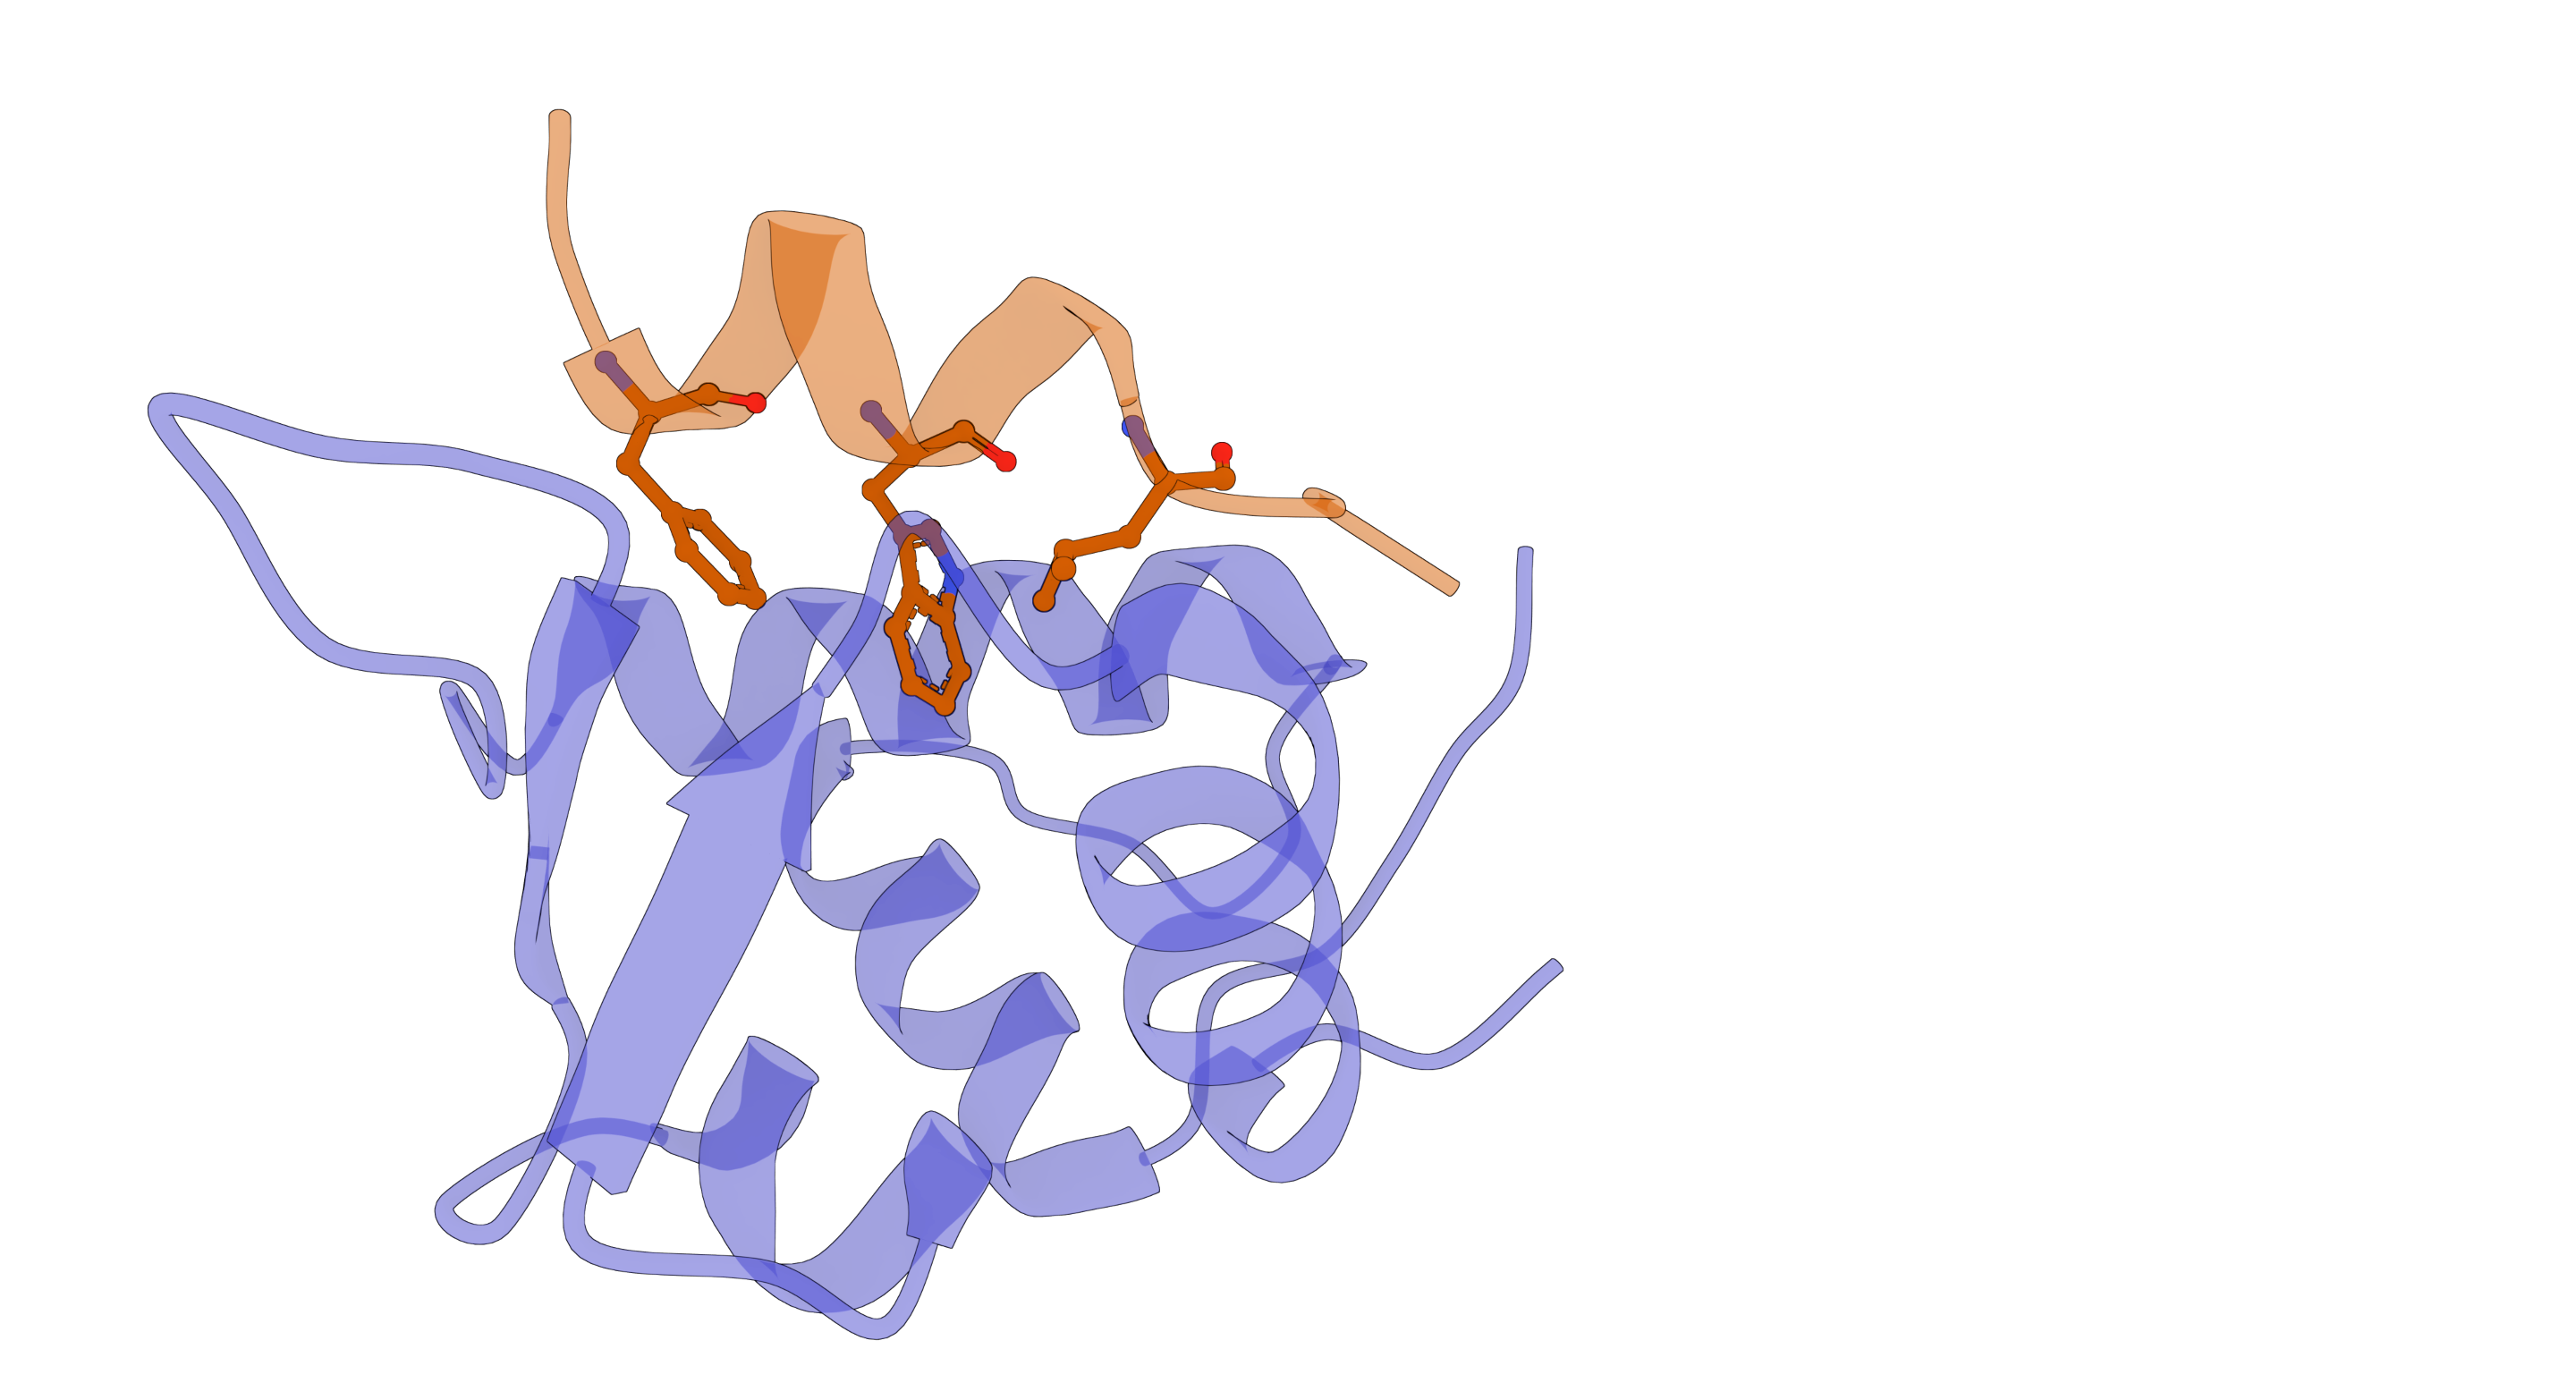

### <font color='#F6ADCD'>**Ten en cuenta**</font>
La gramática del `contig` en RFD3:

| Símbolo | Significado |
|---|---|
| `,` | separa los elementos del contig |
| `B17-29` | residuos 17-29 de la cadena B **del archivo de entrada**, fijos |
| `/0` | ruptura de cadena |
| `20-50` | RFD3 **diseña** un segmento de entre 20 y 50 residuos |

`length` restringe la longitud total, y debe ser consistente con la suma de todos los
segmentos. Para el contig de abajo: 20-50 + 13 (p53) + 20-50 = 53 a 113.

*OJO: si estuviéramos corriendo cada herramienta por separado tendríamos que darle
instrucciones adicionales a MPNN para que rediseñe solo lo nuevo y no el motivo ni el
blanco. Aquí eso se controla con `cadenas_disenadas`.*

In [ ]:
#@title Descargar y mostrar la estructura original
codigo_motivo = "1ycr" #@param {type:"string"}
ruta_1ycr, aa_1ycr = preparar_pdb(codigo_motivo)
ver(aa_1ycr, color="chain")

In [ ]:
#@title Ejecutar RFD3 para *scaffolding*
#@markdown Toma la hélice de p53 (cadena B) como motivo y construye un backbone nuevo
#@markdown a su alrededor, manteniendo a MDM2 (cadena A) como blanco.
contig = "A25-109,/0,0-70,B17-29,0-70" #@param {type:"string"}
longitud_total = "98-238" #@param {type:"string"}
pasos = 100 #@param ["25", "50", "100", "150", "200"] {type:"raw"}
n_disenos = 1 #@param ["1", "2", "4"] {type:"raw"}
semilla = 42 #@param {type:"integer"}
sin_loops = True #@param {type:"boolean"}
#@markdown Ajustes de baja temperatura: menos diversidad, diseños más compactos
step_scale = 3.0 #@param {type:"number"}
gamma_0 = 0.2 #@param {type:"number"}
#@markdown El `ori_token` se calcula solo: empuja el andamio hacia el lado expuesto al
#@markdown solvente, alejándolo de MDM2. Sin eso RFD3 reparte hélices alrededor del
#@markdown blanco en vez de construir un dominio compacto.

# el ORI va desde la helice hacia afuera, alejandose de MDM2
_aa = PDBFile.read(ruta_1ycr).get_structure(model=1)
_aa = _aa[_aa.element != "H"]
_motivo = _aa[(_aa.chain_id == "B") & (_aa.res_id >= 17) & (_aa.res_id <= 29)]
_blanco = _aa[(_aa.chain_id == "A") & (_aa.res_id >= 25) & (_aa.res_id <= 109)]
_v = _motivo.coord.mean(0) - _blanco.coord.mean(0)
_v = _v / np.linalg.norm(_v)
ori_token = [float(x) for x in (_motivo.coord.mean(0) + 10.0 * _v)]
print("ori_token calculado:", np.round(ori_token, 1))

spec_motivo = DesignInputSpecification(
    input=ruta_1ycr,
    contig=contig,
    length=longitud_total,
    ori_token=ori_token,
    is_non_loopy=sin_loops,
)
salidas_motivo = disenar(spec=spec_motivo, n_disenos=n_disenos, pasos=pasos,
                         semilla=semilla, step_scale=step_scale, gamma_0=gamma_0)

In [ ]:
#@title Mostrar estructura 3D {run: "auto"}
animate = "none" #@param ["none", "movie", "interactive"]
color = "chain" #@param ["rainbow", "chain", "bfactor"]
superficie = False #@param {type:"boolean"}
dpi = 100 #@param ["100", "200", "400"] {type:"raw"}

mostrar(salidas_motivo, animate=animate, color=color, dpi=dpi, superficie=superficie)

In [ ]:
#@title Validar el andamio con **MPNN** y **RF3**
indice = 0 #@param {type:"integer"}
num_seqs = 8 #@param ["1", "2", "4", "8", "16"] {type:"raw"}
temperatura = 0.1 #@param ["0.0001", "0.1", "0.2", "0.3", "0.5"] {type:"raw"}
cual_replegar = 0 #@param {type:"integer"}
vista = "cadena" #@param ["cadena", "plddt"]

andamio = elegir(salidas_motivo, indice)
resumen(andamio, "andamio p53")
disenadas, fijas = identificar_cadenas(andamio, entrada=ruta_1ycr)
resultado_motivo = validar(andamio, n_secuencias=num_seqs, temperatura=temperatura,
                           cadenas_disenadas=disenadas, plantilla=fijas,
                           cual_replegar=cual_replegar, vista=vista)

In [ ]:
#@title Guardar y liberar memoria
guardar_peliculas = False #@param {type:"boolean"}
liberar_memoria = True #@param {type:"boolean"}
descargar_modelos = False #@param {type:"boolean"}
#@markdown - `guardar_peliculas`: incluye las trayectorias de denoising. Pesan.
#@markdown - `liberar_memoria`: borra las variables de este ejercicio. Si lo activas,
#@markdown   ya no puedes volver a correr las celdas de arriba sin repetir el diseño.
#@markdown - `descargar_modelos`: saca MPNN y RF3 de la GPU. Se recargan solos.

guardar_ejercicio("4_andamio_p53",
                  salidas=salidas_motivo, estructura=andamio,
                  resultado=resultado_motivo, entrada=ruta_1ycr,
                  trayectorias=guardar_peliculas)
if liberar_memoria:
    liberar("salidas_motivo", "andamio", "resultado_motivo",
            modelos=descargar_modelos)

## **<font color='#4FD1C5'> 5. Diseño de binders</font>**

El siguiente objetivo es diseñar un binder completamente nuevo. Las proteínas de unión
sirven para marcar o interrogar sistemas biológicos, y como punto de partida de
terapéuticos.

### <font color='#F6ADCD'>Ejemplo</font>
Vamos a diseñar una proteína de unión al receptor de insulina
(PDB [`4ZXB`](https://www.rcsb.org/structure/4zxb), cadena E), sin especificar *a priori*
la topología del binder.

En RFD3 los *hotspots* no son una lista suelta de residuos: son un diccionario que apunta a **átomos concretos** del blanco. Y en vez de adivinar dónde poner el centro de masa del binder, usamos `infer_ori_strategy="hotspots"`, que lo coloca 10 Å hacia afuera del centro de los hotspots.

Se recomienda además, específicamente para binders, subir `step_scale` a 3 y bajar
`gamma_0` a 0.2: diseños de menor "temperatura", menos diversos pero mucho más
designables.

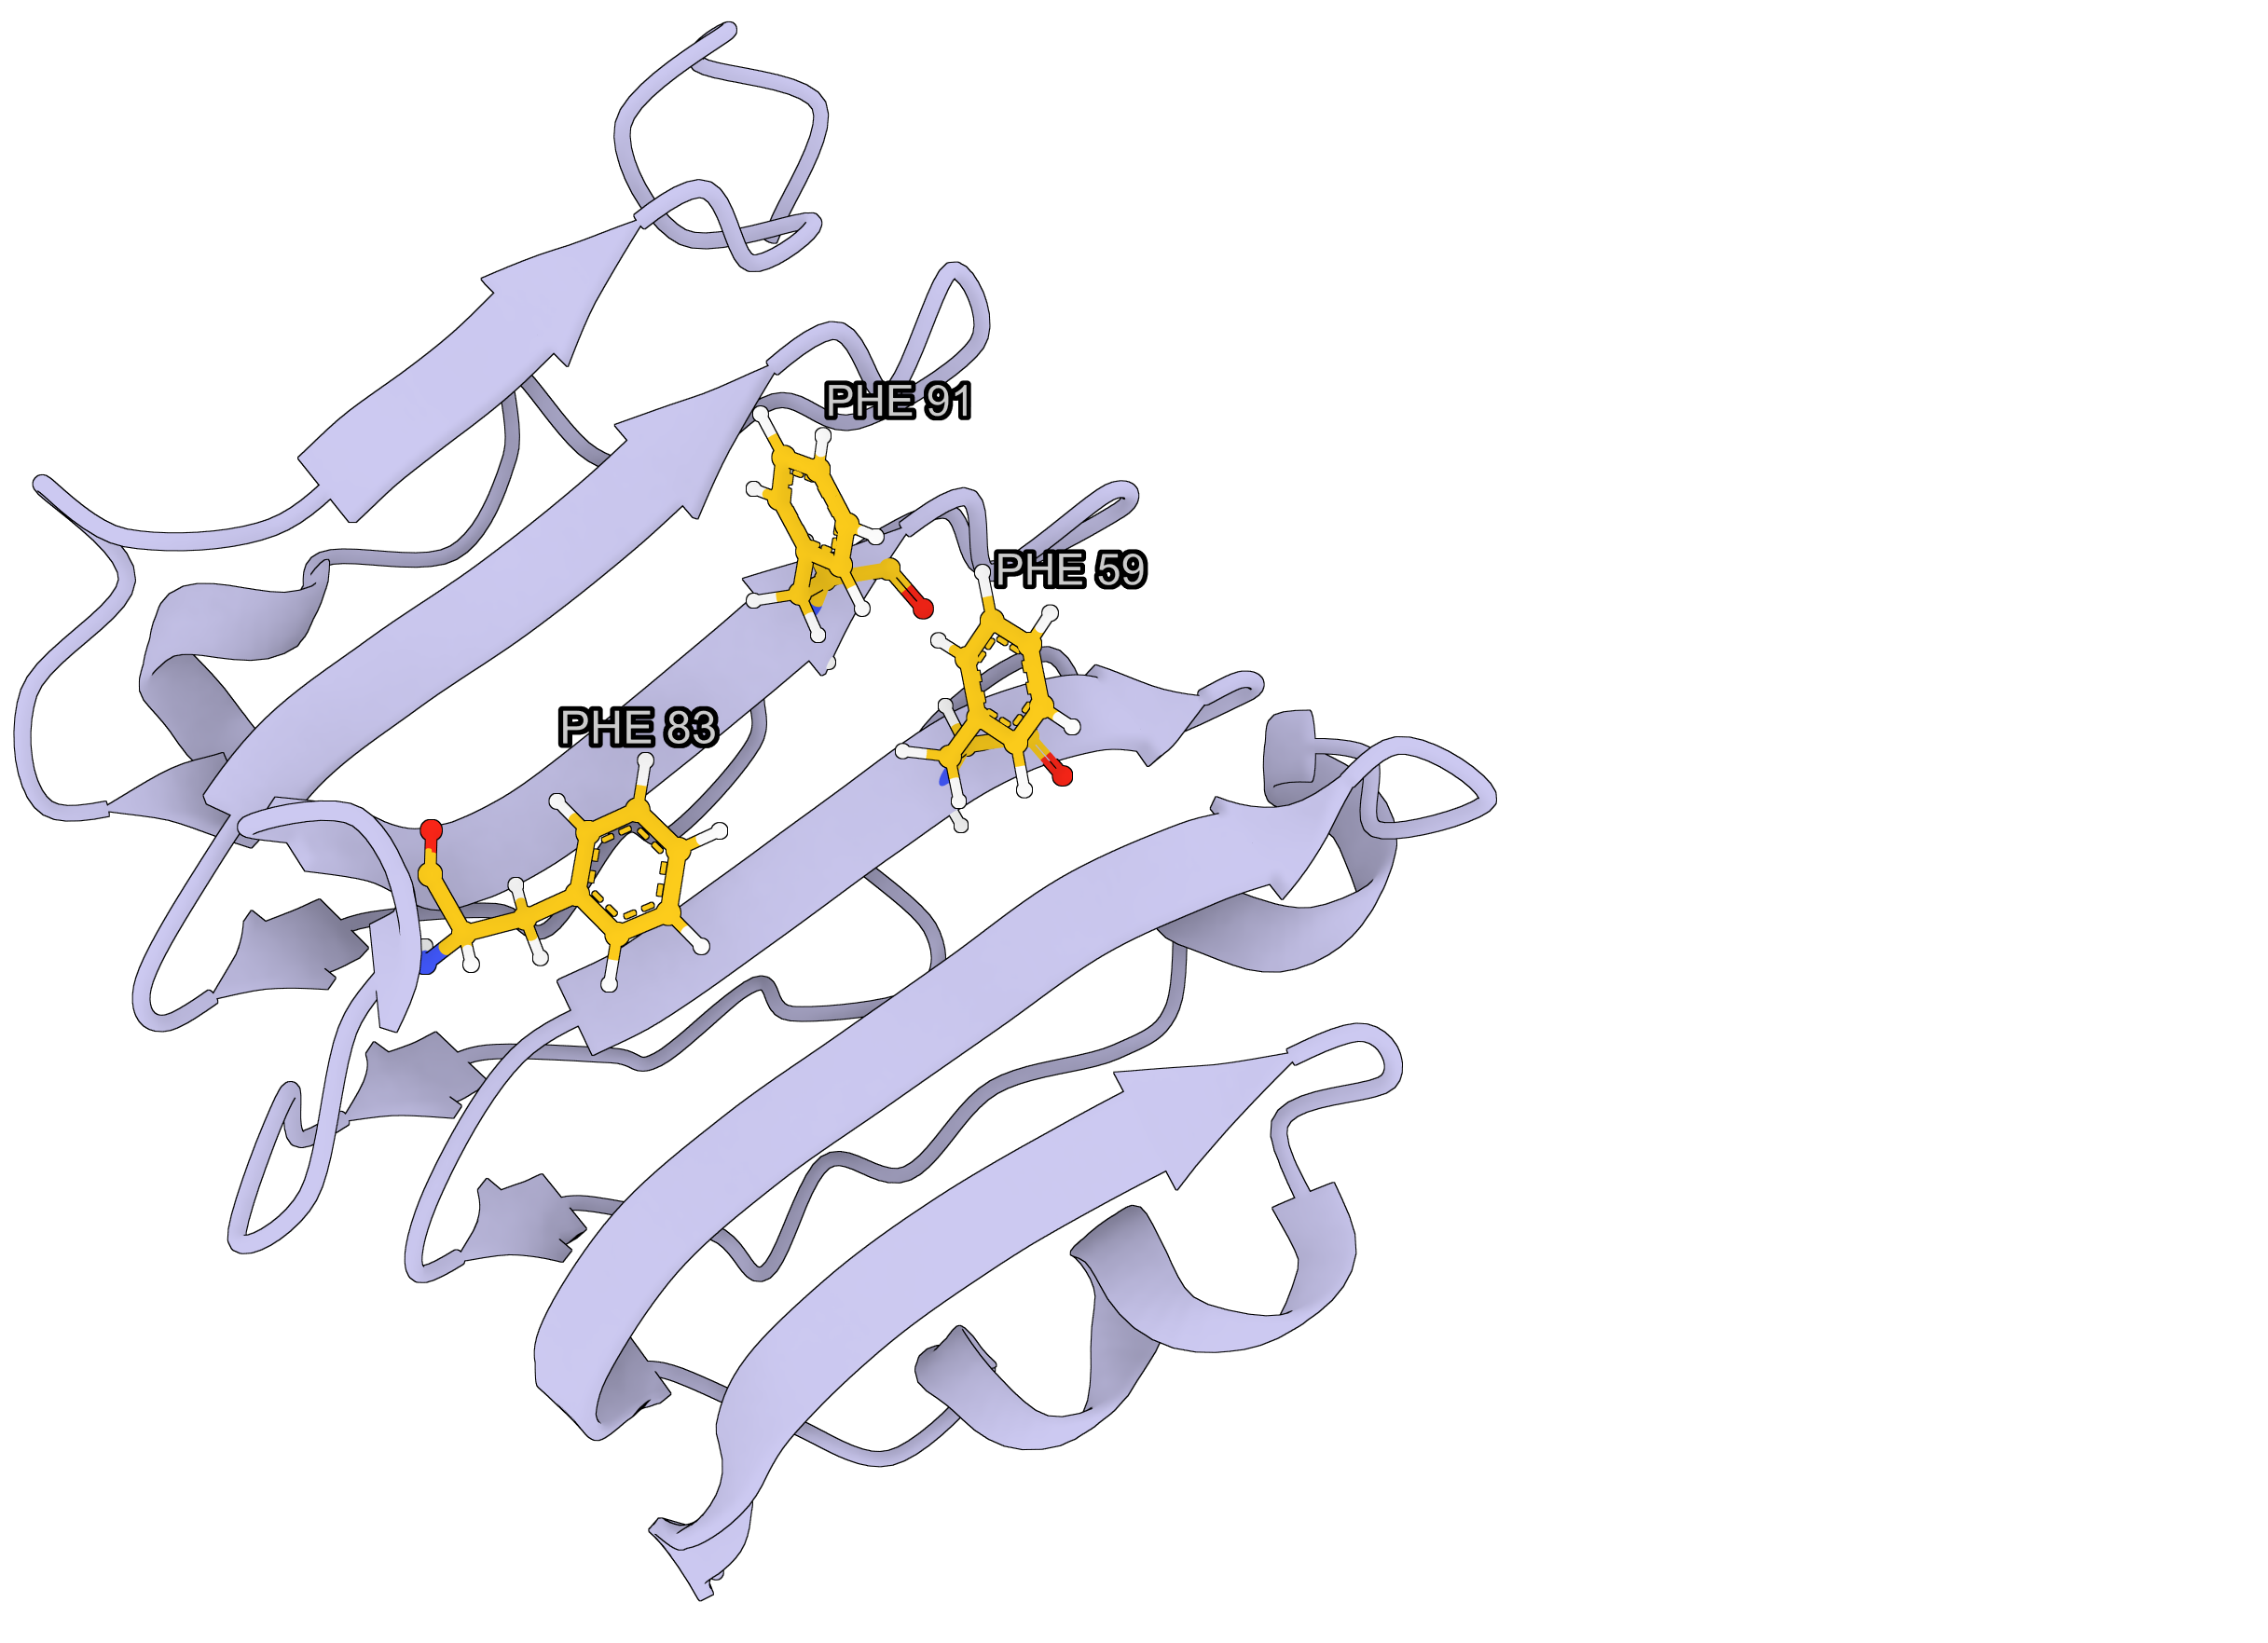

In [ ]:
#@title Descargar y mostrar el receptor de insulina
#@markdown Usamos el archivo recortado que publica el IPD para su tutorial de diseño de
#@markdown interfaces: es la cadena E de 4ZXB, residuos 6-155, ya limpia. Recortar a mano
#@markdown desde la PDB completa da resultados peores.
url_blanco = "https://raw.githubusercontent.com/RosettaCommons/foundry/production/models/rfd3/docs/input_pdbs/4zxb_cropped.pdb" #@param {type:"string"}

ruta_blanco = "4zxb_cropped.pdb"
if not os.path.isfile(ruta_blanco):
    os.system(f"wget -q -O {ruta_blanco} {url_blanco}")

if not os.path.isfile(ruta_blanco) or os.path.getsize(ruta_blanco) == 0:
    print("No se pudo descargar el blanco. Revisa tu conexion.")
else:
    aa_blanco = PDBFile.read(ruta_blanco).get_structure(model=1)
    aa_blanco = aa_blanco[aa_blanco.element != "H"]
    print(f"{ruta_blanco}: {len(aa_blanco)} atomos")
    for c in sorted(set(str(x) for x in aa_blanco.chain_id)):
        sub = aa_blanco[aa_blanco.chain_id == c]
        ids = sorted(set(sub.res_id))
        print(f"  cadena {c}: residuos {ids[0]}-{ids[-1]} ({len(ids)} residuos)")
    ver(aa_blanco, color="chain")

In [ ]:
#@title Ejecutar **RFD3** para diseño de binder
#@markdown `contig` define primero el binder a diseñar (un rango de longitud) y después
#@markdown el blanco, separados por una ruptura de cadena.
contig = "40-120,/0,E6-155" #@param {type:"string"}
longitud_total = "190-270" #@param {type:"string"}
hotspots = {"E64": "CD2,CZ", "E88": "CG,CZ", "E96": "CD1,CZ"} #@param {type:"string"}
pasos = 50 #@param ["25", "50", "100", "150", "200"] {type:"raw"}
n_disenos = 1 #@param ["1", "2", "4"] {type:"raw"}
semilla = 42 #@param {type:"integer"}
sin_loops = True #@param {type:"boolean"}
#@markdown Ajustes recomendados para binders
step_scale = 3.0 #@param {type:"number"}
gamma_0 = 0.2 #@param {type:"number"}




spec_binder = DesignInputSpecification(
    input=ruta_blanco,
    contig=contig,
    length=longitud_total,
    infer_ori_strategy="hotspots",
    select_hotspots=hotspots,
    is_non_loopy=sin_loops,
)
salidas_binder = disenar(spec=spec_binder, n_disenos=n_disenos, pasos=pasos,
                         semilla=semilla, step_scale=step_scale, gamma_0=gamma_0)

In [ ]:
#@title Mostrar estructura 3D {run: "auto"}
animate = "none" #@param ["none", "movie", "interactive"]
color = "chain" #@param ["rainbow", "chain", "bfactor"]
superficie = True #@param {type:"boolean"}
dpi = 100 #@param ["100", "200", "300"] {type:"raw"}

mostrar(salidas_binder, animate=animate, color=color, dpi=dpi, superficie=superficie)

In [ ]:
#@title Validar el binder con **MPNN** y **RF3**
indice = 0 #@param {type:"integer"}
num_seqs = 8 #@param ["1", "2", "4", "8", "16"] {type:"raw"}
temperatura = 0.1 #@param ["0.0001", "0.1", "0.2", "0.3", "0.5"] {type:"raw"}
cual_replegar = 0 #@param {type:"integer"}
vista = "plddt" #@param ["cadena", "plddt"]
#@markdown Para binders, la métrica que importa es el **ipTM**, no solo el RMSD:
#@markdown mide la confianza del modelo en la interfaz, no en cada cadena por separado.

binder = elegir(salidas_binder, indice)
resumen(binder, "binder + receptor de insulina")
disenadas, fijas = identificar_cadenas(binder, entrada=ruta_blanco)
resultado_binder = validar(binder, n_secuencias=num_seqs, temperatura=temperatura,
                           cadenas_disenadas=disenadas, plantilla=fijas,
                           cual_replegar=cual_replegar, vista=vista)

In [ ]:
#@title Guardar y liberar memoria
guardar_peliculas = False #@param {type:"boolean"}
liberar_memoria = True #@param {type:"boolean"}
descargar_modelos = True #@param {type:"boolean"}
#@markdown - `guardar_peliculas`: incluye las trayectorias de denoising. Pesan.
#@markdown - `liberar_memoria`: borra las variables de este ejercicio. Si lo activas,
#@markdown   ya no puedes volver a correr las celdas de arriba sin repetir el diseño.
#@markdown - `descargar_modelos`: saca MPNN y RF3 de la GPU. Se recargan solos.

guardar_ejercicio("5_binder_insulina",
                  salidas=salidas_binder, estructura=binder,
                  resultado=resultado_binder, entrada=ruta_blanco,
                  trayectorias=guardar_peliculas)
if liberar_memoria:
    liberar("salidas_binder", "binder", "resultado_binder",
            modelos=descargar_modelos)

### <font color='#F6ADCD'>Ejercicio</font>
Prueba otro blanco: PD-L1 (`5o45`, cadena A), con
`contig = "50-120,/0,A17-131"` y hotspots `{"A56": "CG,OH", "A115": "CG,SD", "A123": "CD2,OH"}`.
Es el segundo ejemplo.

## **<font color='#4FD1C5'> 6. Simetría</font>**

En este ejemplo vamos a generar un oligómero con simetría C6: seis cadenas idénticas
alrededor de un eje.

En RFD3 la simetría se pide de dos maneras a la vez, y hay que hacer las dos:
1. En la especificación, `symmetry = {"id": "C6"}`. Solo hay soporte para grupos
   cíclicos (`C`) y diédricos (`D`).
2. En el muestreador, `kind = "symmetry"`. Eso es lo que hace `simetria=True` en nuestro
   envoltorio.

`longitud` aquí es la longitud de la **subunidad**, no del ensamble completo. Y conviene
dejar `n_disenos = 1`: la simetría multiplica el uso de memoria y en una T4 se llena
rápido.

In [ ]:
#@title Ejecutar **RFD3** para diseño simétrico
grupo = "C6" #@param ["C2", "C3", "C4", "C5", "C6", "C8", "D2", "D3", "D4"]
longitud_subunidad = "20-50" #@param {type:"string"}
pasos = 50 #@param ["25", "50", "100", "150", "200"] {type:"raw"}
semilla = 42 #@param {type:"integer"}
sin_loops = True #@param {type:"boolean"}

salidas_sim = disenar(
    spec={"length": longitud_subunidad,
          "is_non_loopy": sin_loops,
          "symmetry": {"id": grupo}},
    n_disenos=1, pasos=pasos, semilla=semilla, simetria=True)

In [ ]:
#@title Mostrar estructura 3D {run: "auto"}
animate = "none" #@param ["none", "movie", "interactive"]
color = "chain" #@param ["rainbow", "chain", "bfactor"]
superficie = False #@param {type:"boolean"}
dpi = 100 #@param ["100", "200", "400"] {type:"raw"}

mostrar(salidas_sim, animate=animate, color=color, dpi=dpi, superficie=superficie)

In [ ]:
#@title Comprobar que la simetría es real
oligomero = elegir(salidas_sim, 0)
resumen(oligomero, f"oligomero simetrico")

# Si la simetria se aplico bien, todas las cadenas deben tener el mismo numero de
# residuos y sus centros de masa deben estar a la misma distancia del eje.
centro = oligomero.coord.mean(0)
print("\nCadena | residuos | distancia del centro de masa al eje")
for c in sorted(set(oligomero.chain_id)):
    sub = oligomero[oligomero.chain_id == c]
    n = len(set(sub.res_id))
    d = np.linalg.norm(sub.coord.mean(0) - centro)
    print(f"   {c}   |    {n:3d}   |  {d:.1f} A")
print("\nSi las distancias no son practicamente iguales, la simetria no se aplico.")

In [ ]:
#@title Validar el oligómero con **MPNN** y **RF3**
indice = 0 #@param {type:"integer"}
num_seqs = 4 #@param ["1", "2", "4", "8"] {type:"raw"}
temperatura = 0.1 #@param ["0.0001", "0.1", "0.2", "0.3", "0.5"] {type:"raw"}
subunidad = "A" #@param {type:"string"}
replegar_ensamble_completo = False #@param {type:"boolean"}
vista = "plddt" #@param ["cadena", "plddt"]
#@markdown MPNN ata las secuencias de todas las subunidades: un homo-oligómero de verdad
#@markdown lleva la misma secuencia repetida, no seis secuencias distintas.
#@markdown
#@markdown Por defecto RF3 repliega **una sola subunidad**, no el ensamble: seis cadenas
#@markdown de 80 residuos son 480 tokens y en una T4 se queda sin memoria. Validamos que
#@markdown el protómero sea diseñable; validar el ensamble completo pide más GPU.

disenadas, fijas = identificar_cadenas(oligomero)
resultado_sim = validar(oligomero, n_secuencias=num_seqs, temperatura=temperatura,
                        cadenas_disenadas=disenadas,
                        homo_oligomero=True,
                        replegar_solo=None if replegar_ensamble_completo else subunidad,
                        vista=vista)

In [ ]:
#@title Guardar y liberar memoria
guardar_peliculas = False #@param {type:"boolean"}
liberar_memoria = True #@param {type:"boolean"}
descargar_modelos = False #@param {type:"boolean"}
#@markdown - `guardar_peliculas`: incluye las trayectorias de denoising. Pesan.
#@markdown - `liberar_memoria`: borra las variables de este ejercicio. Si lo activas,
#@markdown   ya no puedes volver a correr las celdas de arriba sin repetir el diseño.
#@markdown - `descargar_modelos`: saca MPNN y RF3 de la GPU. Se recargan solos.

guardar_ejercicio("6_simetria",
                  salidas=salidas_sim, estructura=oligomero,
                  resultado=resultado_sim, trayectorias=guardar_peliculas)
if liberar_memoria:
    liberar("salidas_sim", "oligomero", "resultado_sim",
            modelos=descargar_modelos)

---

## **<font color='#4FD1C5'> 7. Diseño de enzimas</font>**

Hasta ahora condicionamos la difusión con proteína (el andamio de p53, el receptor de
insulina). Ahora el condicionante es una **molécula pequeña**.

El punto de partida se llama **teozima**: el sitio activo aislado, sin la proteína que lo
sostenía. Nada más los residuos catalíticos flotando en la geometría correcta alrededor
del sustrato. La pregunta del diseño de enzimas es exactamente esa: *dada esta
configuración de átomos, ¿qué proteína la sostiene en su lugar?*

Usamos el ejemplo documentado por el RFD3, derivado de `1MG5`:
cuatro residuos catalíticos (Asn108, Ser139, Tyr152, Lys156) más dos ligandos, NAI (el cofactor NADH) y ACT (acetato).

Aparecen dos ideas nuevas:

| Campo | Qué hace |
|---|---|
| `ligand` | nombres de los ligandos que entran en el diseño, separados por comas |
| `unindex` | residuos que **deben** estar, pero cuya posición en la secuencia decide el modelo |

`unindex` es la diferencia clave con el andamiaje de la sección 4. Allá dijimos "la hélice
de p53 va aquí, en estas posiciones". Aquí decimos "necesito una Ser, una Tyr, una Lys y
una Asn con esta geometría relativa; tú decide en qué parte de la cadena ponerlas". Eso es
mucho más difícil y mucho más útil: es como funciona un sitio activo de verdad, con
residuos que en la secuencia están lejísimos y en el espacio se tocan.

`select_fixed_atoms` dice qué átomos de cada residuo son intocables. Para Ser139 son
`OG,CB,CA`: la punta que hace la química. Para NAI la cadena vacía significa que el
cofactor entero puede reorientarse.

### <font color='#F6ADCD'>Predice</font>
El diseño tendrá entre 180 y 200 residuos, y solo cuatro de ellos son catalíticos.
¿Cuántos residuos esperas que terminen tocando al cofactor? Piensa un número antes de
correr.

In [ ]:
#@title Descargar la teozima
#@markdown Es el archivo de entrada exacto que usa el ejemplo de diseño de
#@markdown enzimas: solo el sitio activo, sin la proteína original.
url_teozima = "https://raw.githubusercontent.com/RosettaCommons/foundry/production/models/rfd3/docs/input_pdbs/M0255_1mg5.pdb" #@param {type:"string"}

archivo_teozima = "teozima_1mg5.pdb"
if not os.path.isfile(archivo_teozima):
    os.system(f"wget -q -O {archivo_teozima} {url_teozima}")

if not os.path.isfile(archivo_teozima) or os.path.getsize(archivo_teozima) == 0:
    print("No se pudo descargar la teozima. Revisa tu conexion.")
else:
    aa_teozima = PDBFile.read(archivo_teozima).get_structure(model=1)
    print(f"{len(aa_teozima)} atomos en total. Contenido:")
    for c in sorted(set(str(x) for x in aa_teozima.chain_id)):
        sub = aa_teozima[aa_teozima.chain_id == c]
        for rid in sorted(set(sub.res_id)):
            r = sub[sub.res_id == rid]
            print(f"   cadena {c}  {r.res_name[0]:>4} {rid:<5} ({len(r)} atomos)")
    print("\n  ASN/SER/TYR/LYS: los residuos cataliticos")
    print("  NAI: el cofactor NADH   |   ACT: acetato")
    print("  ORI: no es una molecula, es el token que marca donde debe caer el diseño")
    ver_palitos(aa_teozima)

In [ ]:
#@title Ejecutar **RFD3** para diseñar la enzima
#@markdown Parámetros para este ejemplo.
ligandos = "NAI,ACT" #@param {type:"string"}
residuos_cataliticos = "A108,A139,A152,A156" #@param {type:"string"}
longitud_total = "180-200" #@param {type:"string"}
pasos = 50 #@param ["25", "50", "100", "150", "200"] {type:"raw"}
n_disenos = 1 #@param ["1", "2", "4"] {type:"raw"}
semilla = 0 #@param {type:"integer"}

atomos_fijos = {
    "A108": "ND2,CG",        # Asn: la amida
    "A139": "OG,CB,CA",      # Ser: el hidroxilo nucleofilico
    "A152": "OH,CZ",         # Tyr: el hidroxilo del anillo
    "A156": "NZ,CE,CD",      # Lys: la amina
    "ACT": "OXT",
    "NAI": "",               # vacio: el cofactor puede reorientarse
}

spec_enzima = DesignInputSpecification(
    input=archivo_teozima,
    ligand=ligandos,
    unindex=residuos_cataliticos,
    length=longitud_total,
    select_fixed_atoms=atomos_fijos,
)
salidas_enzima = disenar(spec=spec_enzima, n_disenos=n_disenos, pasos=pasos,
                         semilla=semilla)

In [ ]:
#@title Mostrar estructura 3D {run: "auto"}
animate = "none" #@param ["none", "movie", "interactive"]
color = "rainbow" #@param ["rainbow", "chain", "bfactor"]
superficie = False #@param {type:"boolean"}
sitio = 5.0 #@param {type:"number"}
dpi = 100 #@param ["100", "200", "400"] {type:"raw"}
#@markdown `sitio`: radio en angstroms para dibujar en palitos los residuos que rodean al
#@markdown ligando. Ponlo en 0 para no dibujarlos. Solo se ve con `animate = none`.

mostrar(salidas_enzima, animate=animate, color=color, dpi=dpi,
        superficie=superficie, sitio=sitio)

In [ ]:
#@title Evaluar el bolsillo y validar con **MPNN** y **RF3**
indice = 0 #@param {type:"integer"}
num_seqs = 8 #@param ["1", "2", "4", "8", "16"] {type:"raw"}
temperatura = 0.1 #@param ["0.0001", "0.1", "0.2", "0.3", "0.5"] {type:"raw"}
cual_replegar = 0 #@param {type:"integer"}
vista = "plddt" #@param ["cadena", "plddt"]

enzima = elegir(salidas_enzima, indice)
resumen(enzima, "enzima diseñada")

n_cerca, d_min = contactos_ligando(enzima, ["NAI", "ACT"], corte=5.0)
print(f"\n=== Bolsillo ===")
print(f"  residuos a menos de 5 A del cofactor o el sustrato: {n_cerca}")
print(f"  distancia minima proteina-ligando                 : {d_min:.2f} A")
print("  Un bolsillo real enterrado suele tener 15-25 residuos en contacto.")
print("  Pocos contactos = el ligando quedo en la superficie, no dentro.")

disenadas, fijas = identificar_cadenas(enzima, entrada=archivo_teozima)
resultado_enzima = validar(enzima, n_secuencias=num_seqs, temperatura=temperatura,
                           tipo_mpnn="ligand_mpnn",
                           cadenas_disenadas=disenadas,
                           cual_replegar=cual_replegar, vista=vista)

In [ ]:
#@title Guardar y liberar memoria
guardar_peliculas = False #@param {type:"boolean"}
liberar_memoria = True #@param {type:"boolean"}
descargar_modelos = False #@param {type:"boolean"}
#@markdown - `guardar_peliculas`: incluye las trayectorias de denoising. Pesan.
#@markdown - `liberar_memoria`: borra las variables de este ejercicio. Si lo activas,
#@markdown   ya no puedes volver a correr las celdas de arriba sin repetir el diseño.
#@markdown - `descargar_modelos`: saca MPNN y RF3 de la GPU. Se recargan solos.
guardar_ejercicio("7_enzima",
                  salidas=salidas_enzima, estructura=enzima,
                  resultado=resultado_enzima, entrada=archivo_teozima,
                  trayectorias=guardar_peliculas)
if liberar_memoria:
    liberar("salidas_enzima", "enzima", "resultado_enzima",
            modelos=descargar_modelos)

### <font color='#F6ADCD'>Lee lo que acaba de pasar, y lo que no</font>

Hay una trampa en esta validación, y vale la pena decirla en voz alta.

**MPNN rediseña también los residuos catalíticos.** Le pedimos que proponga secuencias
para todo el andamio, y no sabe que esa Ser y esa Tyr son las que hacen la química: para
él son cuatro posiciones más. Si comparas la secuencia de MPNN contra la de RFD3 en esas
posiciones, es probable que las haya cambiado. En un pipeline real se fijan con
`fixed_residues`, usando la numeración de salida, que hay que sacar del
`diffused_index_map` en `salida.metadata` porque `unindex` movió los residuos de lugar.

**Y el RMSD bajo no dice que la enzima catalice.** Dice que la secuencia recupera el
andamio. La geometría del sitio activo, que es lo único que importa aquí, se mide con el
RMSD de esos cuatro residuos catalíticos entre el diseño y el replegado, no con el RMSD
global. Las tasas de éxito experimental en diseño *de novo* de enzimas siguen siendo
bajas, y la actividad de las que funcionan suele estar órdenes de magnitud por debajo de
una enzima natural.

Esto no es un defecto del ejercicio: es el estado del campo. Diseñar una proteína que se
pliegue es un problema esencialmente resuelto. Diseñar una que *haga* algo, no.

---

## **<font color='#F6AD55'> 8. Unión a ácidos nucleicos</font>**

Este ejercicio sigue el
[tutorial de diseño de binders de ácidos nucleicos de RFdiffusion3](https://rosettacommons.github.io/foundry/models/rfd3/tutorials/na_binder_tutorial.html).

El planteamiento es el mismo que con proteínas: le damos a RFD3 una estructura de RNA,
fijamos sus residuos con el contig, y le pedimos que construya una cadena de proteína
nueva alrededor. La diferencia es que aquí sí conviene usar `ori_token`, la coordenada
`[x, y, z]` donde queremos que caiga el centro de masa de lo diseñado: es la forma de
decirle de qué lado del RNA queremos la proteína.

Usamos **1Q75** como blanco, un RNA de 15 nucleótidos.

In [ ]:
#@title Descargar y mostrar el RNA blanco
codigo_rna = "1q75" #@param {type:"string"}
ruta_rna, aa_rna = preparar_pdb(codigo_rna, cadenas="A")
ver(aa_rna, color="chain")

In [ ]:
#@title Ejecutar **RFD3** para diseñar un binder de RNA
contig = "A1-15,/0,120-130" #@param {type:"string"}
longitud_total = "135-145" #@param {type:"string"}
ori_token = "15,2,-4" #@param {type:"string"}
pasos = 50 #@param ["25", "50", "100", "150", "200"] {type:"raw"}
n_disenos = 1 #@param ["1", "2", "4"] {type:"raw"}
semilla = 0 #@param {type:"integer"}
sin_loops = True #@param {type:"boolean"}
#@markdown `longitud_total` es la suma de todos los polímeros: 15 (RNA) + 120 a 130.
#@markdown Si cambias de PDB, ajusta también `ori_token` usando el centro de masa que
#@markdown imprime la celda anterior.

spec_rna = DesignInputSpecification(
    input=ruta_rna,
    contig=contig,
    length=longitud_total,
    ori_token=[float(x) for x in ori_token.split(",")],
    is_non_loopy=sin_loops,
)
salidas_rna = disenar(spec=spec_rna, n_disenos=n_disenos, pasos=pasos, semilla=semilla)

In [ ]:
#@title Mostrar estructura 3D {run: "auto"}
animate = "movie" #@param ["none", "movie", "interactive"]
color = "chain" #@param ["rainbow", "chain", "bfactor"]
superficie = False #@param {type:"boolean"}
dpi = 100 #@param ["100", "200", "400"] {type:"raw"}

mostrar(salidas_rna, animate=animate, color=color, dpi=dpi, superficie=superficie)

In [ ]:
#@title Evaluar la interfaz proteína-RNA y validar
indice = 0 #@param {type:"integer"}
num_seqs = 8 #@param ["1", "2", "4", "8", "16"] {type:"raw"}
temperatura = 0.1 #@param ["0.0001", "0.1", "0.2", "0.3", "0.5"] {type:"raw"}
cual_replegar = 0 #@param {type:"integer"}
vista = "plddt" #@param ["cadena", "plddt"]
#@markdown MPNN corre en modo `ligand_mpnn` para que **vea** el RNA como contexto. Con
#@markdown `protein_mpnn` diseñaría como si el RNA no existiera y la interfaz saldría
#@markdown hidrofóbica en vez de básica.

binder_rna = elegir(salidas_rna, indice)
resumen(binder_rna, "binder de RNA")
print("\n  Referencia: una interfaz proteina-RNA real suele tener 15-30 residuos en")
print("  contacto. Menos de ~8 sugiere que la proteina apenas roza el RNA: mueve el")
print("  ori_token hacia el centro de masa del RNA y vuelve a correr.")

disenadas, fijas = identificar_cadenas(binder_rna, entrada=ruta_rna)
resultado_rna = validar(binder_rna, n_secuencias=num_seqs, temperatura=temperatura,
                        tipo_mpnn="ligand_mpnn",
                        cadenas_disenadas=disenadas, plantilla=fijas,
                        cual_replegar=cual_replegar, vista=vista)

In [ ]:
#@title Guardar y liberar memoria
guardar_peliculas = False #@param {type:"boolean"}
liberar_memoria = True #@param {type:"boolean"}
descargar_modelos = False #@param {type:"boolean"}
#@markdown - `guardar_peliculas`: incluye las trayectorias de denoising. Pesan.
#@markdown - `liberar_memoria`: borra las variables de este ejercicio. Si lo activas,
#@markdown   ya no puedes volver a correr las celdas de arriba sin repetir el diseño.
#@markdown - `descargar_modelos`: saca MPNN y RF3 de la GPU. Se recargan solos.

guardar_ejercicio("8_binder_rna",
                  salidas=salidas_rna, estructura=binder_rna,
                  resultado=resultado_rna, entrada=ruta_rna,
                  trayectorias=guardar_peliculas)
if liberar_memoria:
    liberar("salidas_rna", "binder_rna", "resultado_rna",
            modelos=descargar_modelos)

### <font color='#F6ADCD'>Lo que este ejercicio no hace, y hay que decirlo</font>

El RNA aquí está **rígido**: lo fijamos por completo. Un RNA real, y sobre todo una
ribozima, cambia de conformación al unirse. Los días 1 y 2 de este taller existen
precisamente porque modelar esa flexibilidad requiere dinámica molecular. Diseñar contra
una sola conformación congelada es una aproximación, no la realidad.

Si quieres soltar el RNA parcialmente, existe `select_fixed_atoms`. Por ejemplo
`select_fixed_atoms={"A1-4": "", "A5-11": "ALL", "A12-15": ""}` fija el centro y deja
que los extremos se relajen.

### <font color='#F6AD55'>El ejemplo completo del tutorial (si sobra tiempo)</font>
El tutorial llega a un caso mucho más rico sobre `2R5Z`: dsDNA parcialmente fijo,
un motivo proteico indexado, un motivo **no indexado** (residuos que deben estar en el
diseño pero cuya posición en la secuencia da igual) y condicionamiento de puentes de
hidrógeno. La celda siguiente lo arma tal cual.

Ojo: `select_hbond_donor` y `select_hbond_acceptor` requieren HBPLUS instalado. Sin él vas
a ver advertencias, pero el diseño corre igual.

In [ ]:
#@title Ejemplo completo del tutorial: dsDNA + motivo no indexado (opcional)
usar_hbond = True #@param {type:"boolean"}
pasos = 50 #@param ["25", "50", "100", "150", "200"] {type:"raw"}
semilla = 6894 #@param {type:"integer"}

ruta_2r5z, aa_2r5z = preparar_pdb("2r5z", cadenas="ABCD")

campos = dict(
    input=ruta_2r5z,
    contig="C5-18,/0,D24-37,/0,40-50,A146-154,80-90",
    length="157-177",
    unindex="/0,/0,B251-255",
    select_fixed_atoms={"C9-14": "ALL", "D28-33": "ALL",
                        "C5-8,C15-18": "", "D24-27,D34-37": ""},
    ori_token=[25.0, 35.0, 20.0],
    is_non_loopy=True,
)
if usar_hbond:
    campos["select_hbond_acceptor"] = {"C16": "N7,O6", "D31-32": "N7",
                                       "D28-30": "OP1,OP2,O3',O5'"}
    campos["select_hbond_donor"] = {"D31-32": "N6"}

salidas_2r5z = disenar(spec=DesignInputSpecification(**campos),
                       n_disenos=1, pasos=pasos, semilla=semilla)
complejo_2r5z = elegir(salidas_2r5z, 0)
resumen(complejo_2r5z, "2R5Z rediseñado")
ver(complejo_2r5z, color="chain")

In [ ]:
#@title Empaquetar todo en un zip
nombre_zip = "taller_diseno_resultados" #@param {type:"string"}
#@markdown Junta todas las carpetas de ejercicios en un solo archivo.
#@markdown Si montaste Drive, el zip queda ahí y lo bajas desde drive.google.com.

empaquetar_todo(nombre_zip)
uso_de_memoria("al final")

## **<font color='#4FD1C5'> 8. Ejemplos e instrucciones</font>**
---

El `contig` define qué se toma del archivo de entrada y qué se diseña. Los elementos se
separan con comas, las rupturas de cadena son `/0`, y un número o rango sin letra de
cadena significa "diseña esto".

**No condicionada**
- `longitud="100"` difunde un monómero de longitud 100.
- `longitud="50-100"` diseña un monómero de entre 50 y 100 residuos.
- `contig="50,/0,100"` diseña un hetero-oligómero de longitudes 50 y 100.

**Andamiaje**
- `contig="40,A163-181,40"` con `input=5tpn`: usa los residuos 163-181 de la cadena A como
  motivo y difunde dos segmentos de 40 residuos a cada extremo.
- `contig="A3-30,36,A33-68"` con `input=6mrr`: difunde un loop de 36 residuos entre los dos
  segmentos.

**Binders**
- `contig="70-100,/0,A1-150"` más `select_hotspots={"A59": "CB", "A83": "CB", "A91": "CB"}`
  e `infer_ori_strategy="hotspots"`.

**Difusión parcial**
- `contig="A1-100"`, `partial_t=5.0`: mantiene la topología de la entrada y la remuestrea.
  Empieza con valores pequeños (2-5 Å) y súbelos poco a poco; arriba de 15 Å ya no se
  parece a la entrada.

**Motivos no indexados**
- `unindex="A244,A274,A320"`: esos residuos deben aparecer en el diseño, pero el modelo
  decide en qué posición de la secuencia. Es lo que se usa para andamiar sitios activos.

**Simetría**
- `symmetry={"id": "C3"}` más `simetria=True`.

**Selección de átomos** (para `select_fixed_atoms`, `select_hotspots`, etc.)
- `"ALL"` todos los átomos, `"BKBN"` el backbone, `"TIP"` los átomos de la punta de la
  cadena lateral, `""` ninguno (es decir, deja que el modelo los mueva), o una lista
  explícita como `"N,CA,C,O,CB"`.

## **<font color='#4FD1C5'>9. Ejercicios libres</font>**
La celda siguiente deja todos los campos abiertos. Deja vacío lo que no quieras usar.

In [ ]:
#@title Correr **RFD3** con la configuración que quieras
entrada = "" #@param {type:"string"}
contig = "" #@param {type:"string"}
longitud = "100" #@param {type:"string"}
ori_token = "" #@param {type:"string"}
estrategia_ori = "" #@param ["", "com", "hotspots"]
hotspots = "" #@param {type:"string"}
unindex = "" #@param {type:"string"}
partial_t = 0.0 #@param {type:"number"}
grupo_simetria = "" #@param ["", "C2", "C3", "C4", "C5", "C6", "D2", "D3", "D4"]
sin_loops = True #@param {type:"boolean"}
n_disenos = 1 #@param ["1", "2", "4", "8"] {type:"raw"}
pasos = 50 #@param ["25", "50", "100", "150", "200"] {type:"raw"}
semilla = 0 #@param {type:"integer"}
#@markdown - `entrada`: código PDB de 4 letras (se descarga solo) o ruta a un archivo
#@markdown - `hotspots`: lista de residuos, p.ej. `A59,A83,A91` (se fijan sus átomos CB)
#@markdown - `partial_t` > 0 activa la difusión parcial

ruta = entrada.strip()
if ruta and not os.path.isfile(ruta):
    ruta, _ = preparar_pdb(ruta)

campos = {"is_non_loopy": sin_loops}
if ruta:
    campos["input"] = ruta
if contig.strip():
    campos["contig"] = contig.strip()
if longitud.strip():
    campos["length"] = longitud.strip()
if ori_token.strip():
    campos["ori_token"] = [float(x) for x in ori_token.split(",")]
if estrategia_ori:
    campos["infer_ori_strategy"] = estrategia_ori
if hotspots.strip():
    campos["select_hotspots"] = {r.strip(): "CB" for r in hotspots.split(",") if r.strip()}
if unindex.strip():
    campos["unindex"] = unindex.strip()
if partial_t > 0:
    campos["partial_t"] = float(partial_t)
if grupo_simetria:
    campos["symmetry"] = {"id": grupo_simetria}

print("Especificacion:", campos)
if ruta or contig.strip():
    spec_libre = DesignInputSpecification(**campos)
else:
    spec_libre = campos

salidas_libre = disenar(spec=spec_libre, n_disenos=n_disenos, pasos=pasos,
                        semilla=semilla, simetria=bool(grupo_simetria))
libre = elegir(salidas_libre, 0)
resumen(libre, "diseño libre")
print(f"\n  {secuencia(libre)}")

In [ ]:
#@title Mostrar estructura 3D {run: "auto"}
animate = "movie" #@param ["none", "movie", "interactive"]
color = "chain" #@param ["rainbow", "chain", "bfactor"]
superficie = False #@param {type:"boolean"}
dpi = 100 #@param ["100", "200", "400"] {type:"raw"}

mostrar(salidas_libre, animate=animate, color=color, dpi=dpi, superficie=superficie)

In [ ]:
#@title Exportar tus estructuras
from atomworks.io.utils.io_utils import to_cif_file

nombre = "mi_diseno" #@param {type:"string"}
to_cif_file(libre, f"{nombre}.cif")
print(f"Escrito: {nombre}.cif")
print("Descargalo del panel de archivos (izquierda) para abrirlo en PyMOL o ChimeraX.")

---
## **<font color='#4FD1C5'>Para llevarse</font>**

1. **El diseño es un problema inverso**, y funciona porque es muchos-a-uno: muchas
   secuencias dan la misma estructura.
2. **RFD3 ya da secuencia, pero MPNN sigue siendo el paso recomendado.**
3. **La auto-consistencia filtra, no valida.** RMSD < 2 Å y pLDDT > 0.8 significan "vale
   la pena sintetizar esto". La tasa de éxito experimental de los binders que pasan estos
   filtros se mide en por cientos, no en mayorías.
4. **Diseñar contra estructuras rígidas es una aproximación.** Su RNA se mueve; lo que
   diseñamos hoy asume que no.
5. **El cuello de botella ya no es computacional, es experimental.** Generar 10,000 diseños
   toma una tarde. Probarlos toma meses.

### Referencias
- RFdiffusion: Watson et al., *Nature* 618, 1089 (2023)
- RFdiffusion3: Butcher et al., *bioRxiv* (2025), doi:10.1101/2025.09.18.676967
- ProteinMPNN: Dauparas et al., *Science* 378, 49 (2022)
- LigandMPNN: Dauparas et al., *Nature Methods* (2025)
- AtomWorks y RF3: Corley et al., *bioRxiv* (2025)
- AlphaFold2: Jumper et al., *Nature* 596, 583 (2021)
- Documentación de foundry: https://rosettacommons.github.io/foundry/
- Notebook original de RFdiffusion clásico, de Sergey Ovchinnikov:
  https://colab.research.google.com/github/sokrypton/ColabDesign/blob/main/rf/examples/diffusion.ipynb

---
